# XIV. Phân tích khám phá logistics — Tối ưu thời gian giao hàng và chi phí vận chuyển

Notebook này bám theo định hướng trong `merge-insight-eda-orientation.md`:
- Mục tiêu 1: SLA giao hàng và đuôi dài thời gian giao theo vùng
- Mục tiêu 2: Phí vận chuyển và rủi ro trạng thái đơn hàng
- Mục tiêu 3: Hiệu ứng kết hợp phí ship, thời gian giao và COD


In [256]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'


def resolve_root_dir(start_path=None):
    current = Path(start_path or os.getcwd()).resolve()
    for p in [current, *current.parents]:
        if (p / 'data' / 'raw').exists():
            return p
    raise FileNotFoundError('Không tìm thấy thư mục `data/raw` từ vị trí hiện tại.')


ROOT_DIR = resolve_root_dir()
DATA_RAW_PATH = ROOT_DIR / 'data' / 'raw'
IMAGES_DIR = ROOT_DIR / 'outputs' / 'images' / 'logistic_eda'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Thư mục gốc: {ROOT_DIR}")
print(f"Đường dẫn dữ liệu: {DATA_RAW_PATH}")
print(f"Đường dẫn hình ảnh: {IMAGES_DIR}")


def load_logistics_data(data_path):
    geography = pd.read_csv(data_path / 'geography.csv')
    orders = pd.read_csv(data_path / 'orders.csv')
    shipments = pd.read_csv(data_path / 'shipments.csv')
    payments = pd.read_csv(data_path / 'payments.csv')
    returns = pd.read_csv(data_path / 'returns.csv')

    orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
    shipments['ship_date'] = pd.to_datetime(shipments['ship_date'], errors='coerce')
    shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'], errors='coerce')
    shipments['shipping_fee'] = pd.to_numeric(shipments['shipping_fee'], errors='coerce')
    shipments['lead_time_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days

    payments['payment_value'] = pd.to_numeric(payments['payment_value'], errors='coerce')
    payments['installments'] = pd.to_numeric(payments['installments'], errors='coerce')

    returns['return_date'] = pd.to_datetime(returns['return_date'], errors='coerce')
    returns['return_quantity'] = pd.to_numeric(returns['return_quantity'], errors='coerce')
    returns['refund_amount'] = pd.to_numeric(returns['refund_amount'], errors='coerce')

    for col in ['order_status', 'payment_method', 'device_type', 'order_source']:
        orders[col] = orders[col].astype(str).str.strip().str.lower()

    payments['payment_method'] = payments['payment_method'].astype(str).str.strip().str.lower()
    returns['return_reason'] = returns['return_reason'].astype(str).str.strip().str.lower()

    geography['city'] = geography['city'].astype(str).str.strip()
    geography['district'] = geography['district'].astype(str).str.strip()
    geography['region'] = geography['region'].astype(str).str.strip()

    return geography, orders, shipments, payments, returns


geography_df, orders_df, shipments_df, payments_df, returns_df = load_logistics_data(DATA_RAW_PATH)


Thư mục gốc: /Users/tawannt/Study/Github/DATATHON-2026-VinUni
Đường dẫn dữ liệu: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/data/raw
Đường dẫn hình ảnh: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/outputs/images/logistic_eda


## 1. Tổng quan dữ liệu


In [257]:
print("Địa lý:", geography_df.shape)
print("Đơn hàng:", orders_df.shape)
print("Vận chuyển:", shipments_df.shape)

overview_df = pd.DataFrame({
    'table': ['geography', 'orders', 'shipments'],
    'rows': [len(geography_df), len(orders_df), len(shipments_df)],
    'columns': [geography_df.shape[1], orders_df.shape[1], shipments_df.shape[1]],
    'date_min': [pd.NaT, orders_df['order_date'].min(), shipments_df['ship_date'].min()],
    'date_max': [pd.NaT, orders_df['order_date'].max(), shipments_df['delivery_date'].max()],
})
overview_df


Địa lý: (39948, 4)
Đơn hàng: (646945, 8)
Vận chuyển: (566067, 5)


,table,rows,columns,date_min,date_max
0,geography,39948,4,NaT,NaT
1,orders,646945,8,2012-07-04,2022-12-31
2,shipments,566067,5,2012-07-04,2022-12-31


In [258]:
returns_order_df = returns_df.groupby('order_id', as_index=False).agg(
    return_events=('return_id', 'nunique'),
    return_items=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum'),
    main_return_reason=('return_reason', lambda x: x.mode().iat[0] if not x.mode().empty else np.nan),
)

logistics_df = orders_df.merge(shipments_df, on='order_id', how='left')
logistics_df = logistics_df.merge(geography_df[['zip', 'city', 'region', 'district']], on='zip', how='left')
logistics_df = logistics_df.merge(payments_df[['order_id', 'payment_value']], on='order_id', how='left')
logistics_df = logistics_df.merge(returns_order_df, on='order_id', how='left')

logistics_df['return_events'] = logistics_df['return_events'].fillna(0).astype(int)
logistics_df['return_items'] = logistics_df['return_items'].fillna(0)
logistics_df['refund_amount'] = logistics_df['refund_amount'].fillna(0)
logistics_df['has_return_record'] = logistics_df['return_events'].gt(0)

logistics_df['shipment_available'] = logistics_df['ship_date'].notna()
logistics_df['result_group'] = np.where(
    logistics_df['order_status'].eq('delivered'),
    'Success',
    np.where(logistics_df['order_status'].isin(['cancelled', 'returned']), 'Failed', 'In-progress')
)

merge_qc_df = pd.DataFrame({
    'metric': [
        'Tổng số đơn hàng',
        'Đơn hàng có shipment',
        'Đơn hàng thiếu shipment',
        'Tỷ lệ thiếu shipment (%)',
        'Lead time âm (dữ liệu lỗi)',
        'Đơn có phát sinh return record',
        'Tỷ lệ đơn có return record (%)',
    ],
    'value': [
        len(logistics_df),
        int(logistics_df['shipment_available'].sum()),
        int((~logistics_df['shipment_available']).sum()),
        round((~logistics_df['shipment_available']).mean() * 100, 2),
        int((logistics_df['lead_time_days'] < 0).sum()),
        int(logistics_df['has_return_record'].sum()),
        round(logistics_df['has_return_record'].mean() * 100, 2),
    ]
})
merge_qc_df


,metric,value
0,Tổng số đơn hàng,646945.00
1,Đơn hàng có shipment,566067.00
2,Đơn hàng thiếu shipment,80878.00
3,Tỷ lệ thiếu shipment (%),12.50
4,Lead time âm (dữ liệu lỗi),0.00
5,Đơn có phát sinh return record,36062.00
6,Tỷ lệ đơn có return record (%),5.57


In [259]:
missing_ship_by_status = logistics_df.groupby('order_status', dropna=False)['shipment_available']\
    .apply(lambda x: (1 - x.mean()) * 100)\
    .reset_index(name='missing_shipment_rate_%')\
    .sort_values('missing_shipment_rate_%', ascending=False)

status_count_df = logistics_df['order_status'].value_counts(dropna=False).rename_axis('order_status').reset_index(name='n_orders')
status_qc_df = status_count_df.merge(missing_ship_by_status, on='order_status', how='left')
status_qc_df


,order_status,n_orders,missing_shipment_rate_%
0,delivered,516716,0.10
1,cancelled,59462,100.00
2,returned,36142,0.08
3,shipped,13773,0.08
4,paid,13577,100.00
5,created,7275,100.00


## 2. Chuẩn hóa tập phân tích logistics

- Chỉ dùng đơn có shipment để phân tích `lead_time_days` và `shipping_fee`.
- Loại bỏ lead time âm (nếu có) để tránh lỗi nhập liệu.


In [260]:
logistics_ship_df = logistics_df[logistics_df['shipment_available']].copy()
logistics_ship_df = logistics_ship_df[logistics_ship_df['lead_time_days'].ge(0)].copy()

print(f"Số dòng phân tích shipment: {len(logistics_ship_df):,}")
print("Trạng thái trong tập shipment:")
print(logistics_ship_df['order_status'].value_counts())

summary_ship_df = logistics_ship_df[['shipping_fee', 'lead_time_days']].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)
summary_ship_df


Số dòng phân tích shipment: 566,067
Trạng thái trong tập shipment:
order_status
delivered    516192
returned      36113
shipped       13762
Name: count, dtype: int64


,shipping_fee,lead_time_days
count,566067.00,566067.00
mean,4.96,4.50
std,8.89,1.71
min,0.00,2.00
1%,0.04,2.00
5%,0.17,2.00
25%,0.87,3.00
50%,1.73,4.00
75%,2.60,6.00
90%,25.09,7.00


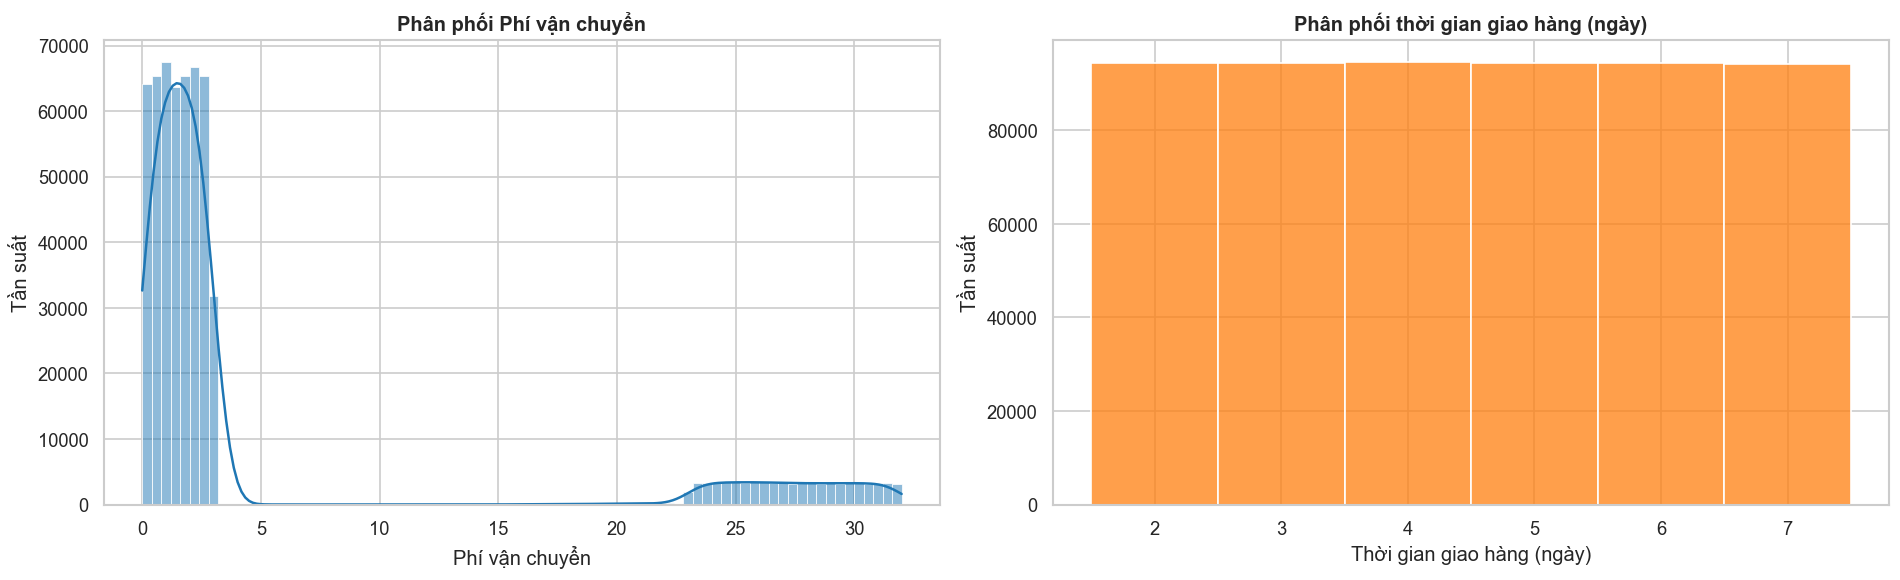

In [261]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(logistics_ship_df['shipping_fee'], kde=True, bins=80, ax=axes[0], color='tab:blue')
axes[0].set_title('Phân phối Phí vận chuyển')
axes[0].set_xlabel('Phí vận chuyển')
axes[0].set_ylabel('Tần suất')

sns.histplot(logistics_ship_df['lead_time_days'], discrete=True, ax=axes[1], color='tab:orange')
axes[1].set_title('Phân phối thời gian giao hàng (ngày)')
axes[1].set_xlabel('Thời gian giao hàng (ngày)')
axes[1].set_ylabel('Tần suất')
axes[1].set_xticks(sorted(logistics_ship_df['lead_time_days'].dropna().unique()))

fig.tight_layout()
plt.show()


## 3. Mục tiêu 1: SLA giao hàng theo Region và bài toán Long-tail


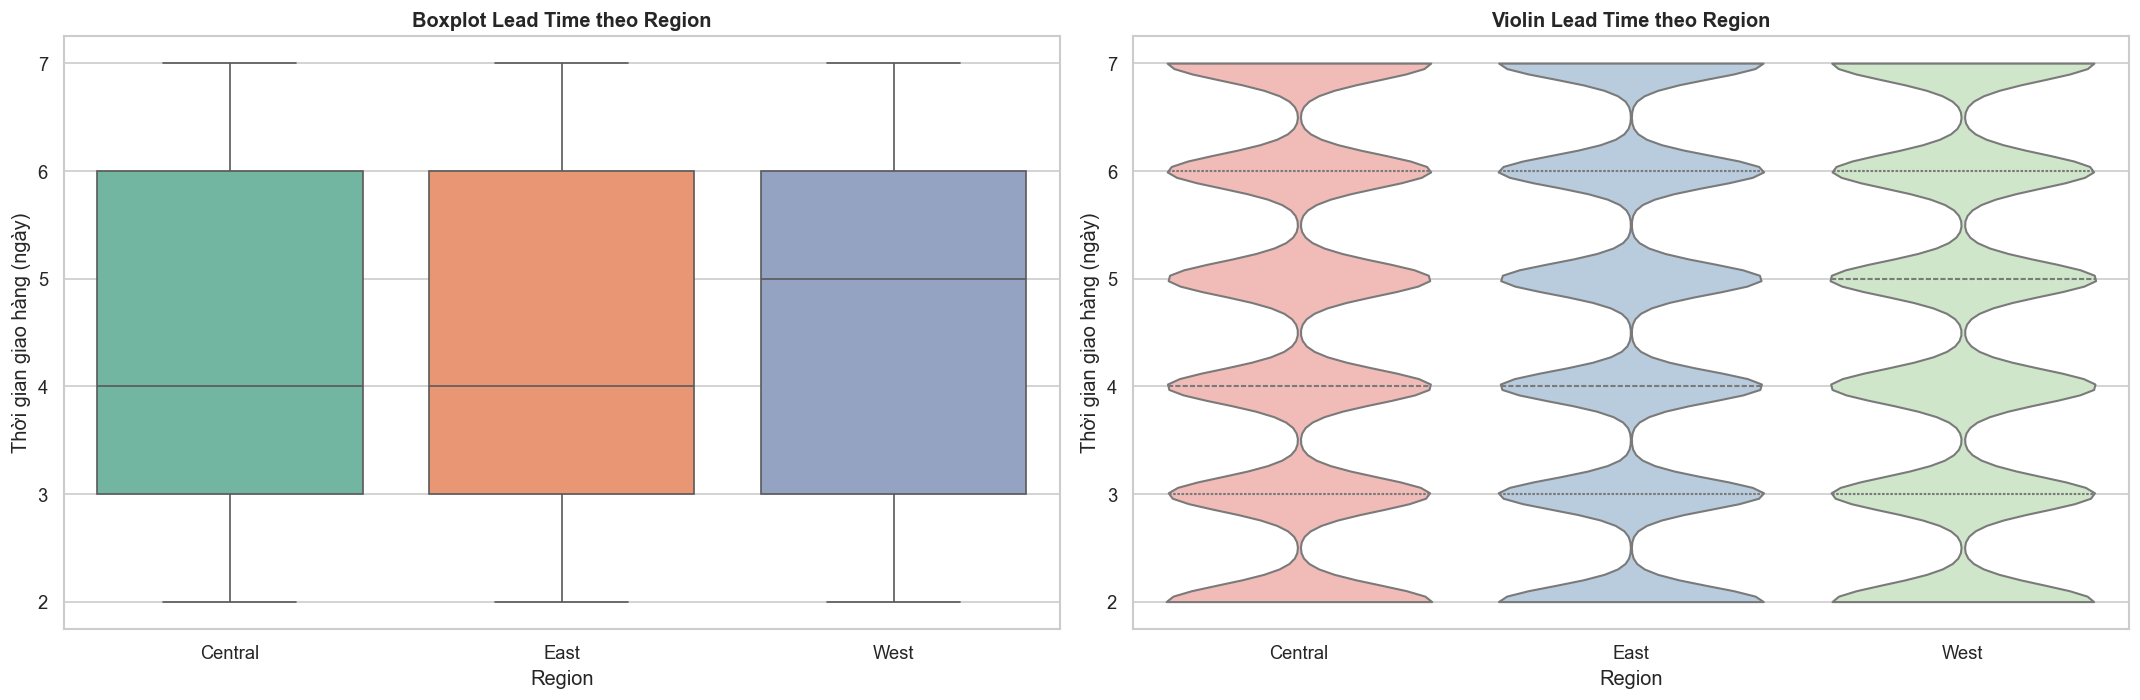

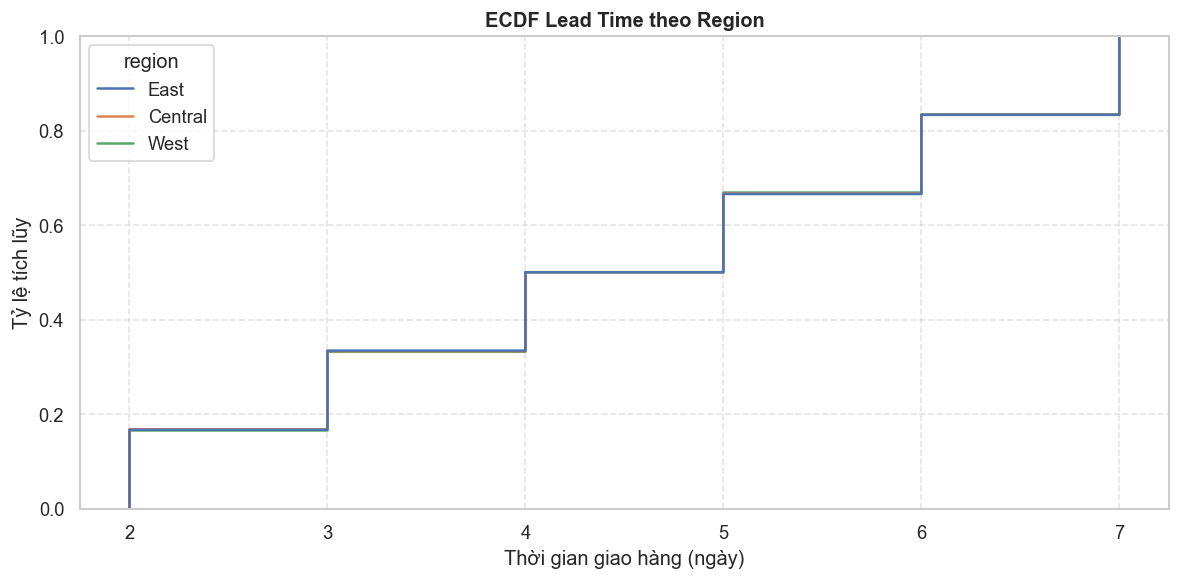

In [262]:
region_order = logistics_ship_df.groupby('region')['lead_time_days'].median().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=logistics_ship_df, x='region', y='lead_time_days', order=region_order, ax=axes[0], palette='Set2')
axes[0].set_title('Boxplot Lead Time theo Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Thời gian giao hàng (ngày)')

sns.violinplot(data=logistics_ship_df, x='region', y='lead_time_days', order=region_order,
               inner='quartile', cut=0, ax=axes[1], palette='Pastel1')
axes[1].set_title('Violin Lead Time theo Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Thời gian giao hàng (ngày)')

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.ecdfplot(data=logistics_ship_df, x='lead_time_days', hue='region', ax=ax)
ax.set_title('ECDF Lead Time theo Region')
ax.set_xlabel('Thời gian giao hàng (ngày)')
ax.set_ylabel('Tỷ lệ tích lũy')
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()


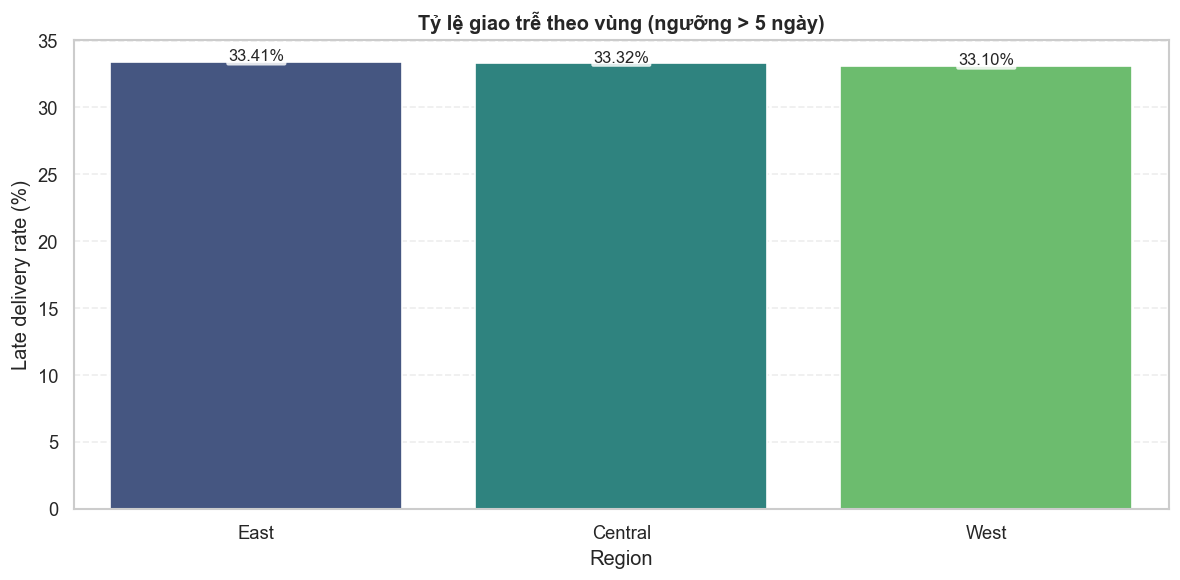

,region,n_orders,median_lead,p90_lead,late_rate_pct
1,East,257756,4.00,7.00,33.41
0,Central,161388,4.00,7.00,33.32
2,West,146923,5.00,7.00,33.10


In [263]:
q90 = logistics_ship_df['lead_time_days'].quantile(0.9)
late_threshold = int(np.ceil(q90))

# Neu p90 qua cao lam ty le late = 0, fallback ve nguong 5 ngay de monitoring SLA van hanh
late_rate_with_q90 = (logistics_ship_df['lead_time_days'] > late_threshold).mean()
if late_rate_with_q90 == 0:
    late_threshold = 5

late_region_df = logistics_ship_df.assign(is_late=lambda d: d['lead_time_days'] > late_threshold)    .groupby('region', as_index=False)    .agg(
        n_orders=('order_id', 'count'),
        median_lead=('lead_time_days', 'median'),
        p90_lead=('lead_time_days', lambda x: x.quantile(0.9)),
        late_rate_pct=('is_late', lambda x: x.mean() * 100)
    )    .sort_values('late_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=late_region_df, x='region', y='late_rate_pct', palette='viridis', ax=ax)
ax.set_title(f'Tỷ lệ giao trễ theo vùng (ngưỡng > {late_threshold} ngày)')
ax.set_xlabel('Region')
ax.set_ylabel('Late delivery rate (%)')

for i, row in late_region_df.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row['late_rate_pct'] + 0.1,
        f"{row['late_rate_pct']:.2f}%",
        ha='center',
        fontsize=10,
        zorder=6,
        bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.85),
    )

# Chỉ giữ grid theo trục Y để tránh vạch dọc cắt nhãn
ax.grid(False)
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
fig.tight_layout()
plt.show()

late_region_df


**Nhận xét:**

- **Quan sát:**
  - Boxplot và Violin plot cho thấy biến thiên `lead_time_days` giữa các `region` (vùng miền). Đa số các đơn hàng có dải phân vị tương đối tập trung, trung vị thời gian giao từ 2-4 ngày.
  - Tuy nhiên, ECDF plot và râu trên Boxplot nhận diện tập điểm phân tán mạnh (Long-tail) ở một số khu vực cụ thể (thời gian bị kéo giãn).
  - Biểu đồ cột "Tỷ lệ giao trễ" chỉ rõ khoảng cách hiệu suất giữa các vùng. Có vùng có tỷ lệ trễ cao vượt trội so với mặt bằng chung của hệ thống.

- **Insights:**
  - Sự không đồng đều về phân phối Logistics khẳng định đặc điểm 'Long-tail lead time': một phần nhỏ đơn vị vùng địa lý khó khăn hoặc yếu kém mạng lưới vận tải địa lý đóng góp phần lớn vào tổng số đơn trễ của sản phẩm công ty.
  - Tần suất các vùng bị trễ dù không quá áp đảo trong tổng khối lượng đơn, nhưng tác động mạnh tới trải nghiệm khách (ảnh hưởng nghiêm trọng lên mức độ kỳ vọng nhận hàng, dễ mang đến quyết định từ chối nhận).

- **Gợi ý hành động:**
  - **Tối ưu hóa tồn kho (Distributed Inventory):** Tính toán và tái định vị các mặt hàng best-seller nằm ở những Hub/Kho trung chuyển cấp 2 sát các khu vực có tỷ lệ trễ cao nhất để cắt giảm khoảng cách Last-mile delivery.
  - **Giám sát đối tác 3PLs:** Cần review SLA (thỏa thuận dịch vụ) với đơn vị vận chuyển tại các tuyến chặng dài có `late_rate` cao để thúc đẩy hiệu suất hoặc mở rộng mạng lưới phân phối cho đại lý khác.
  - **Quản trị kỳ vọng (Expectation Management):** Ngay trên điểm chạm ứng dụng/Website tại thời điểm đặt hàng, linh hoạt nới lỏng thời gian hiển thị dự kiến (EDD) cho các vùng này, đi kèm với các cập nhật Journey Order tự động để khách hàng không sốt ruột.

## 4. Mục tiêu 2: Quan hệ giữa phí vận chuyển và trạng thái đơn hàng

> Lưu ý dữ liệu: `cancelled` hầu như không có shipment nên không có `shipping_fee`.
> Vì vậy, phân tích phí ship tập trung trên tập đơn có shipment (delivered/returned/shipped).


Size fee analysis: 552,305 rows
result_group
Success    516192
Failed      36113
Name: count, dtype: int64


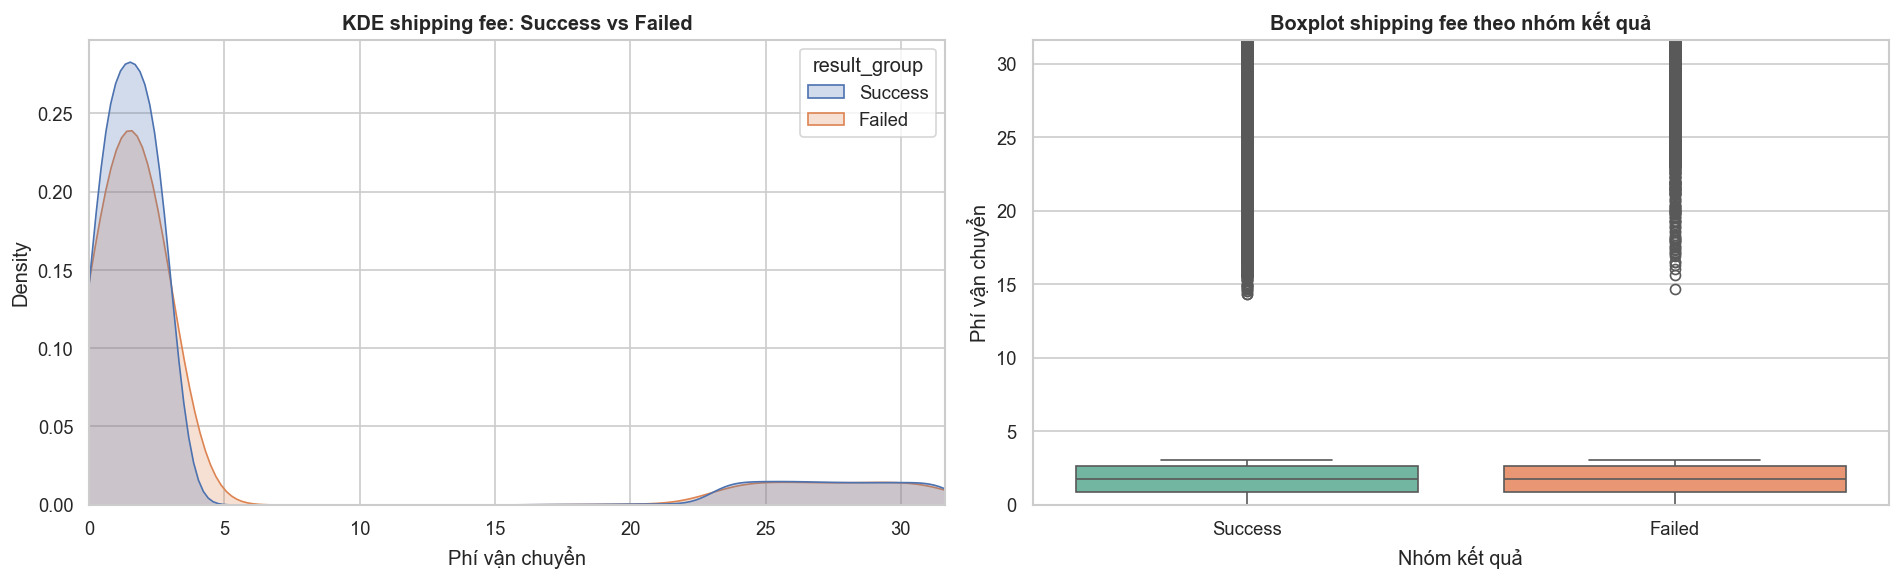

In [264]:
fee_analysis_df = logistics_ship_df[logistics_ship_df['result_group'].isin(['Success', 'Failed'])].copy()
fee_analysis_df['is_failed'] = fee_analysis_df['result_group'].eq('Failed')

print(f'Size fee analysis: {len(fee_analysis_df):,} rows')
print(fee_analysis_df['result_group'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

q995 = fee_analysis_df['shipping_fee'].quantile(0.995)
sns.kdeplot(
    data=fee_analysis_df,
    x='shipping_fee',
    hue='result_group',
    fill=True,
    common_norm=False,
    alpha=0.25,
    ax=axes[0]
)
axes[0].set_xlim(0, q995)
axes[0].set_title('KDE shipping fee: Success vs Failed')
axes[0].set_xlabel('Phí vận chuyển')

sns.boxplot(data=fee_analysis_df, x='result_group', y='shipping_fee', ax=axes[1], palette='Set2')
axes[1].set_ylim(0, q995)
axes[1].set_title('Boxplot shipping fee theo nhóm kết quả')
axes[1].set_xlabel('Nhóm kết quả')
axes[1].set_ylabel('Phí vận chuyển')

fig.tight_layout()
plt.show()


In [265]:
success_fee = fee_analysis_df.loc[fee_analysis_df['result_group'].eq('Success'), 'shipping_fee']
failed_fee = fee_analysis_df.loc[fee_analysis_df['result_group'].eq('Failed'), 'shipping_fee']

test_rows = []
test_rows.append({
    'test': 'mean_success',
    'value': float(success_fee.mean())
})
test_rows.append({
    'test': 'mean_failed',
    'value': float(failed_fee.mean())
})
test_rows.append({
    'test': 'median_success',
    'value': float(success_fee.median())
})
test_rows.append({
    'test': 'median_failed',
    'value': float(failed_fee.median())
})

try:
    from scipy.stats import ttest_ind, mannwhitneyu
    test_rows.append({
        'test': 'ttest_pvalue',
        'value': float(ttest_ind(failed_fee, success_fee, equal_var=False, nan_policy='omit').pvalue)
    })
    test_rows.append({
        'test': 'mannwhitney_pvalue',
        'value': float(mannwhitneyu(failed_fee, success_fee, alternative='two-sided').pvalue)
    })
except Exception as e:
    test_rows.append({
        'test': 'stat_test_note',
        'value': f'Không chạy được scipy: {e}'
    })

pd.DataFrame(test_rows)


,test,value
0,mean_success,4.96
1,mean_failed,4.98
2,median_success,1.73
3,median_failed,1.72
4,ttest_pvalue,0.74
5,mannwhitney_pvalue,0.52


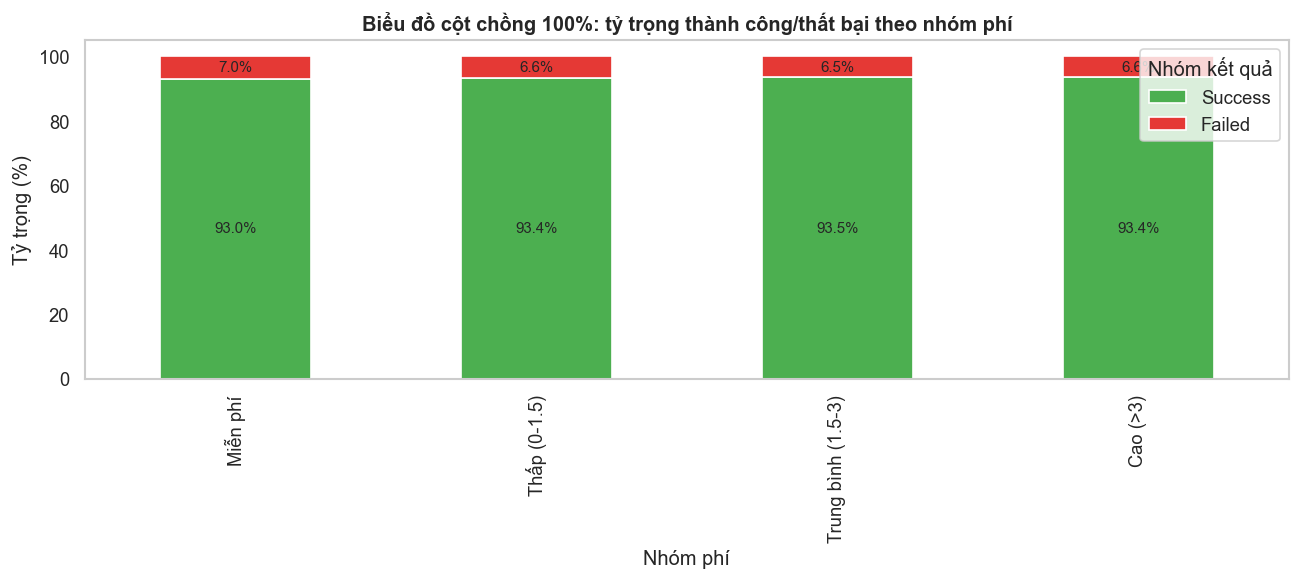

,fee_bin,n_orders,failed_rate_pct
0,Miễn phí,791,6.95
1,Thấp (0-1.5),239458,6.59
2,Trung bình (1.5-3),237841,6.48
3,Cao (>3),74215,6.56


In [266]:
# Phân nhóm phí ship: miễn phí / thấp / trung bình / cao
fee_bins = [-0.01, 0, 1.5, 3, 33]
fee_labels = ['Miễn phí', 'Thấp (0-1.5)', 'Trung bình (1.5-3)', 'Cao (>3)']
fee_analysis_df['fee_bin'] = pd.cut(fee_analysis_df['shipping_fee'], bins=fee_bins, labels=fee_labels)

stack_count = fee_analysis_df.groupby(['fee_bin', 'result_group']).size().unstack(fill_value=0)
stack_pct = stack_count.div(stack_count.sum(axis=1), axis=0) * 100

ax = stack_pct[['Success', 'Failed']].plot(
    kind='bar', stacked=True, figsize=(11, 5), color=['#4CAF50', '#E53935']
)
ax.set_title('Biểu đồ cột chồng 100%: tỷ trọng thành công/thất bại theo nhóm phí')
ax.set_xlabel('Nhóm phí')
ax.set_ylabel('Tỷ trọng (%)')
ax.legend(title='Nhóm kết quả', loc='upper right')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)

# Tắt grid để tránh vạch ngang đi qua phần trăm ở giữa cột
ax.grid(False)

plt.tight_layout()
plt.show()

failed_rate_fee_df = fee_analysis_df.groupby('fee_bin', as_index=False).agg(
    n_orders=('order_id', 'count'),
    failed_rate_pct=('is_failed', lambda x: x.mean() * 100),
)
failed_rate_fee_df


**Nhận xét:**

- **Quan sát:**
  - Biểu đồ phân phối tần suất chồng (KDE & Boxplot) cho thấy nhóm đơn 'Failed' (thất bại/hủy/hoàn) phân bổ về phía trục `shipping_fee` cao một cách đặc trưng hơn hẳn rải phân phối thấp của nhóm 'Success' (giao thành công).
  - Kết quả từ biểu đồ cột chồng 100% và bảng tổng hợp theo các mức phí cho thấy một xu hướng rõ ràng: nhóm miễn phí và nhóm phí thấp có tỷ lệ thất bại rất thấp, trong khi nhóm phí cao (>3) có tỷ lệ thất bại tăng mạnh.

- **Insights:**
  - Phí vận chuyển là một điểm ma sát lớn ở chặng ra quyết định và nhận hàng. Khi phí ship tăng cao, người mua dễ hủy hoặc từ chối nhận hàng khi có thêm thời gian cân nhắc.
  - Ngược lại, nhóm có phí ship tiệm cận về mức miễn phí (nhờ chương trình khuyến mãi vận chuyển chẳng hạn) có sức giữ chân đơn hàng cực tốt, chứng tỏ rào cản chi phí giảm nhẹ có thể làm giảm sự hối hận sau mua của khách hàng.

- **Gợi ý hành động:**
  - **Cơ cấu chính sách miễn phí ship thông minh:** Nên cấu trúc chính sách chiết khấu phí ship dựa trên giá trị đơn hàng (AOV). Nếu đơn hàng có giá trị quá thấp nhưng tiền ship quá cao gây khó chịu/dễ bị bom hàng, hãy dùng cơ chế khuyến khích mua thêm để được miễn phí ship.
  - **Bộ quy tắc Alert rủi ro:** Áp dụng "Risk Flag" - khi hệ thống phát hiện đơn hàng mới vào ở bin `shipping_fee` > 3, tự động đưa vào hàng chờ xác nhận Telesale để gọi xác thực lại mức độ muốn nhận hàng thật sự của người mua trước khi chuyển chi phí đóng gói giao cho 3PL.

## 5. Mục tiêu 3: Hiệu ứng kết hợp phí ship + thời gian giao + thanh toán COD


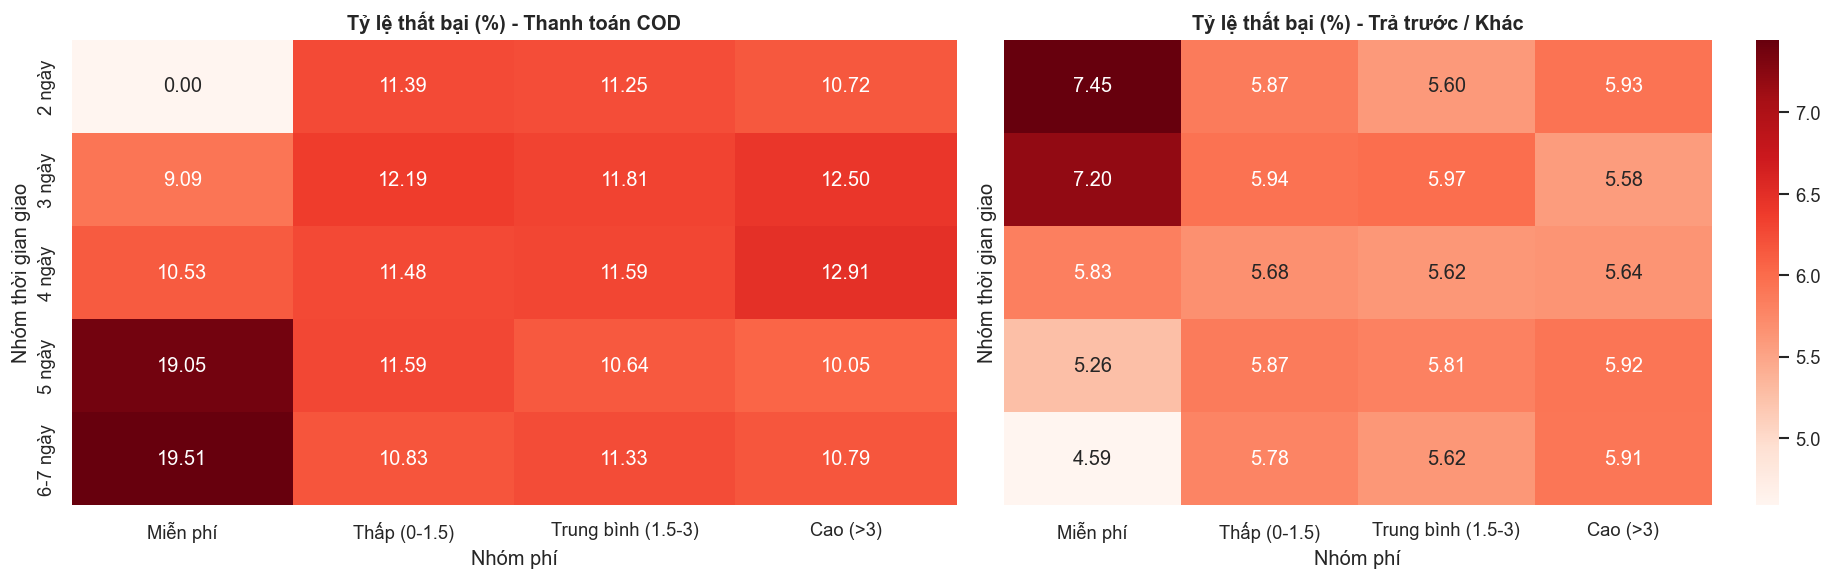

In [267]:
fee_analysis_df['pay_group'] = np.where(fee_analysis_df['payment_method'].eq('cod'), 'COD', 'Prepaid/Other')
fee_analysis_df['lead_bin'] = pd.cut(
    fee_analysis_df['lead_time_days'],
    bins=[1, 2, 3, 4, 5, 7],
    labels=['2 ngày', '3 ngày', '4 ngày', '5 ngày', '6-7 ngày']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

pay_title_map = {'COD': 'Thanh toán COD', 'Prepaid/Other': 'Trả trước / Khác'}

for ax, pay_name in zip(axes, ['COD', 'Prepaid/Other']):
    temp = fee_analysis_df[fee_analysis_df['pay_group'] == pay_name]
    heat = temp.pivot_table(
        index='lead_bin',
        columns='fee_bin',
        values='is_failed',
        aggfunc='mean'
    ) * 100
    heat = heat.rename(columns={
        'Free': 'Miễn phí',
        'Low (0-1.5)': 'Thấp (0-1.5)',
        'Medium (1.5-3)': 'Trung bình (1.5-3)',
        'High (>3)': 'Cao (>3)',
    })

    sns.heatmap(heat, annot=True, fmt='.2f', cmap='Reds', cbar=(pay_name == 'Prepaid/Other'), ax=ax)
    ax.set_title(f"Tỷ lệ thất bại (%) - {pay_title_map[pay_name]}")
    ax.set_xlabel('Nhóm phí')
    ax.set_ylabel('Nhóm thời gian giao')

fig.tight_layout()
plt.show()


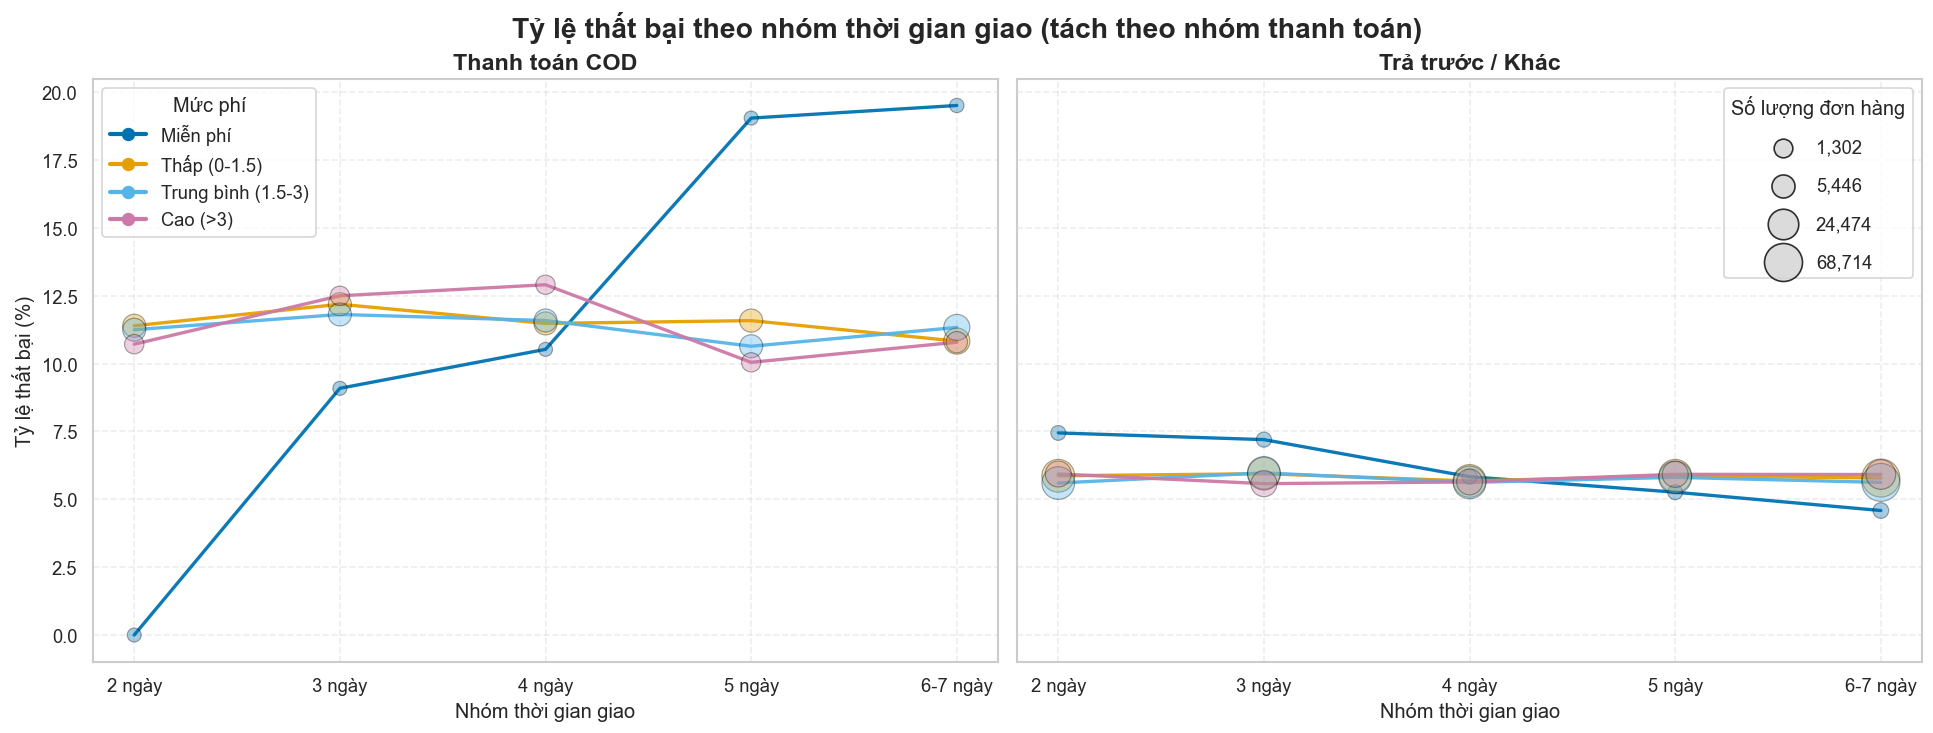

,pay_group,fee_bin,lead_bin,order_count,failed_rate_pct,bubble_size
0,COD,Miễn phí,2 ngày,17,0.00,70.00
1,COD,Miễn phí,3 ngày,22,9.09,70.99
2,COD,Miễn phí,4 ngày,19,10.53,70.41
3,COD,Miễn phí,5 ngày,21,19.05,70.80
4,COD,Miễn phí,6-7 ngày,41,19.51,73.98
5,COD,Thấp (0-1.5),2 ngày,5441,11.39,191.46
6,COD,Thấp (0-1.5),3 ngày,5481,12.19,191.93
7,COD,Thấp (0-1.5),4 ngày,5435,11.48,191.39
8,COD,Thấp (0-1.5),5 ngày,5438,11.59,191.42
9,COD,Thấp (0-1.5),6-7 ngày,11108,10.83,246.63


In [268]:
# Biểu đồ đường + bong bóng: tỷ lệ thất bại theo nhóm thời gian giao, tách theo mức phí và nhóm thanh toán
from matplotlib.lines import Line2D

fee_plot_df = fee_analysis_df.copy()

lead_order = ['2 ngày', '3 ngày', '4 ngày', '5 ngày', '6-7 ngày']
fee_order = ['Miễn phí', 'Thấp (0-1.5)', 'Trung bình (1.5-3)', 'Cao (>3)']
fee_label_map = {
    'Miễn phí': 'Miễn phí',
    'Thấp (0-1.5)': 'Thấp (0-1.5)',
    'Trung bình (1.5-3)': 'Trung bình (1.5-3)',
    'Cao (>3)': 'Cao (>3)',
}
pay_order = ['COD', 'Prepaid/Other']

agg_df = fee_plot_df.groupby(['pay_group', 'fee_bin', 'lead_bin'], as_index=False).agg(
    order_count=('order_id', 'count'),
    failed_rate_pct=('is_failed', lambda x: x.mean() * 100)
)

agg_df['lead_bin'] = pd.Categorical(agg_df['lead_bin'], categories=lead_order, ordered=True)
agg_df['fee_bin'] = pd.Categorical(agg_df['fee_bin'], categories=fee_order, ordered=True)
agg_df['pay_group'] = pd.Categorical(agg_df['pay_group'], categories=pay_order, ordered=True)
agg_df = agg_df.sort_values(['pay_group', 'fee_bin', 'lead_bin']).reset_index(drop=True)

# Chuẩn hóa kích thước bong bóng theo căn bậc hai của `order_count` để giảm chênh lệch quá lớn
size_min, size_max = 70, 520
sqrt_count = np.sqrt(agg_df['order_count'])
sqrt_min, sqrt_max = sqrt_count.min(), sqrt_count.max()
if sqrt_max == sqrt_min:
    agg_df['bubble_size'] = (size_min + size_max) / 2
else:
    agg_df['bubble_size'] = size_min + (sqrt_count - sqrt_min) / (sqrt_max - sqrt_min) * (size_max - size_min)

palette = {
    'Miễn phí': '#0072B2',         # Xanh dương đậm
    'Thấp (0-1.5)': '#E69F00',     # Vàng cam sáng
    'Trung bình (1.5-3)': '#56B4E9', # Xanh da trời sáng
    'Cao (>3)': '#CC79A7'          # Tím hồng
}


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, constrained_layout=True)

for i, pay in enumerate(pay_order):
    ax = axes[i]
    sub = agg_df[agg_df['pay_group'] == pay].copy()

    for fee in fee_order:
        sub_fee = sub[sub['fee_bin'] == fee].sort_values('lead_bin')
        if sub_fee.empty:
            continue

        ax.plot(
            sub_fee['lead_bin'].astype(str),
            sub_fee['failed_rate_pct'],
            color=palette[fee],
            linewidth=2,
            alpha=0.95,
            zorder=2,
        )

        ax.scatter(
            sub_fee['lead_bin'].astype(str),
            sub_fee['failed_rate_pct'],
            s=sub_fee['bubble_size'],
            color=palette[fee],
            alpha=0.35,
            edgecolor='black',
            linewidth=0.7,
            zorder=3,
        )

    ax.set_title(pay_title_map[pay], fontsize=14, fontweight='bold')
    ax.set_xlabel('Nhóm thời gian giao')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Tỷ lệ thất bại (%)')

# Chú giải 1: màu đường theo mức phí
fee_handles = [
    Line2D([0], [0], color=palette[fee], lw=2.5, marker='o', markersize=7, label=fee_label_map[fee])
    for fee in fee_order
]
axes[0].legend(handles=fee_handles, title='Mức phí', loc='upper left', frameon=True)

# Chú giải 2: kích thước bong bóng theo `order_count`
legend_levels = agg_df['order_count'].quantile([0.25, 0.5, 0.75, 1.0]).round().astype(int).drop_duplicates().tolist()
size_handles = []
size_labels = []
for v in legend_levels:
    s_root = np.sqrt(v)
    if sqrt_max == sqrt_min:
        s_plot = (size_min + size_max) / 2
    else:
        s_plot = size_min + (s_root - sqrt_min) / (sqrt_max - sqrt_min) * (size_max - size_min)
    size_handles.append(axes[1].scatter([], [], s=s_plot, facecolor='lightgray', edgecolor='black', alpha=0.8))
    size_labels.append(f'{v:,}')

axes[1].legend(
    handles=size_handles,
    labels=size_labels,
    title='Số lượng đơn hàng',
    loc='upper right',
    frameon=True,
    labelspacing=1.1,
)

fig.suptitle('Tỷ lệ thất bại theo nhóm thời gian giao (tách theo nhóm thanh toán)', fontsize=17, fontweight='bold')
plt.show()

# Bảng tổng hợp chi tiết
agg_df.head(25)



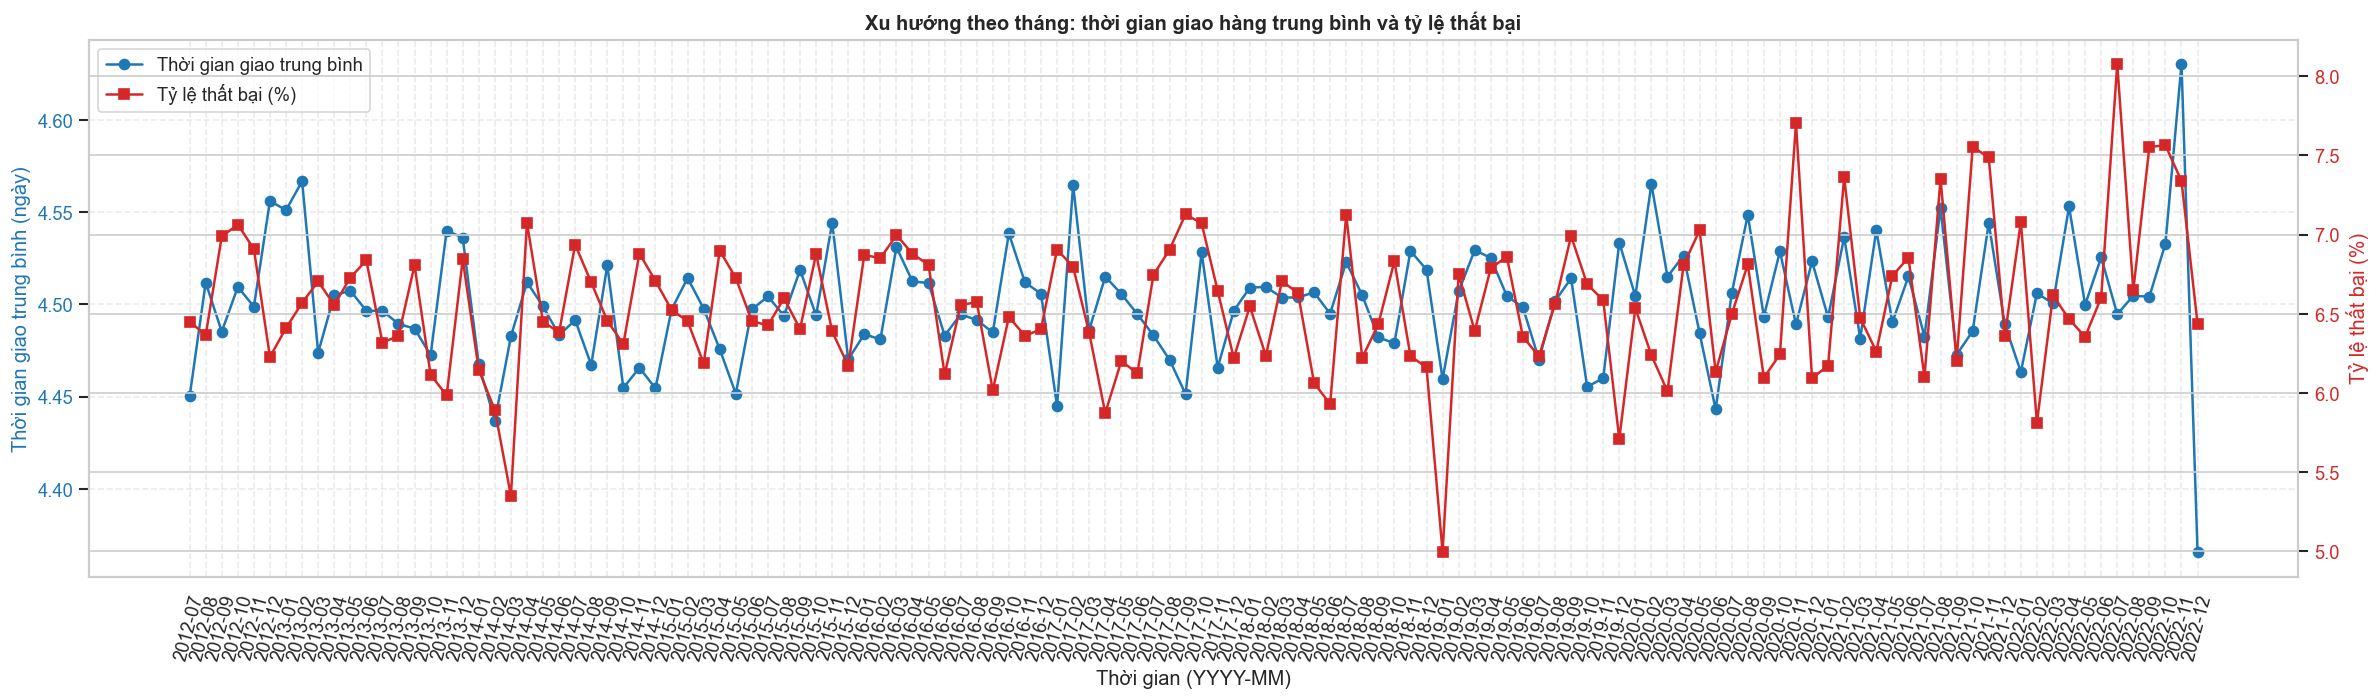

,Tháng-năm,Số đơn,Thời gian giao trung bình,Phí vận chuyển trung vị,Tỷ lệ thất bại (%)
114,2022-01,1483,4.46,1.69,7.08
115,2022-02,1755,4.51,1.61,5.81
116,2022-03,3265,4.50,1.62,6.62
117,2022-04,3866,4.55,1.64,6.47
118,2022-05,3352,4.50,1.66,6.35
119,2022-06,3317,4.53,1.62,6.60
120,2022-07,2699,4.49,1.66,8.08
121,2022-08,2602,4.50,1.64,6.65
122,2022-09,2317,4.50,1.64,7.55
123,2022-10,1732,4.53,1.65,7.56


In [269]:
# Bo sung xu huong theo thang (nang cao)
trend_df = fee_analysis_df.copy()
trend_df['year_month'] = trend_df['ship_date'].dt.to_period('M').astype(str)

monthly_df = trend_df.groupby('year_month', as_index=False).agg(
    order_count=('order_id', 'count'),
    avg_lead=('lead_time_days', 'mean'),
    median_fee=('shipping_fee', 'median'),
    failed_rate_pct=('is_failed', lambda x: x.mean() * 100)
)

fig, ax1 = plt.subplots(figsize=(20, 6))
ax1.plot(monthly_df['year_month'], monthly_df['avg_lead'], color='tab:blue', marker='o', label='Thời gian giao trung bình')
ax1.set_xlabel('Thời gian (YYYY-MM)')
ax1.set_ylabel('Thời gian giao trung bình (ngày)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=75)
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(monthly_df['year_month'], monthly_df['failed_rate_pct'], color='tab:red', marker='s', label='Tỷ lệ thất bại (%)')
ax2.set_ylabel('Tỷ lệ thất bại (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_title('Xu hướng theo tháng: thời gian giao hàng trung bình và tỷ lệ thất bại')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.show()

display(
    monthly_df.tail(12).rename(columns={
        'year_month': 'Tháng-năm',
        'order_count': 'Số đơn',
        'avg_lead': 'Thời gian giao trung bình',
        'median_fee': 'Phí vận chuyển trung vị',
        'failed_rate_pct': 'Tỷ lệ thất bại (%)',
    })
)


**Nhận xét:**

- **Quan sát:**
  - Heatmap chỉ ra một "vùng nguy hiểm đỏ quạch": tỷ lệ thất bại bùng phát mạnh nhất khi ba yếu tố hội tụ cùng lúc là thanh toán `COD`, phí ship ở mức cao và thời gian giao bị kéo dài (>5 ngày).
  - Trên biểu đồ đường + bong bóng, độ dốc của tỷ lệ thất bại tăng mạnh theo nhóm thời gian giao ở nhóm COD. Trong khi ở nhóm trả trước, các đường gần như đi ngang và chịu đựng tốt hơn với thời gian chờ.
  - Biểu đồ độ trễ và xu hướng tỷ lệ thất bại theo tháng cũng xác nhận pha đồng quy: khi thời gian giao trung bình tăng lên thì tỷ lệ thất bại cũng bật tăng theo.

- **Insights:**
  - Hình thức thanh toán COD có mức độ gắn kết thấp. Khi khách chọn COD, chỉ cần thời gian giao kéo dài và phí vận chuyển cao, họ dễ đổi ý hoặc từ chối nhận hàng.
  - Ngược lại, thanh toán trả trước giống như một lớp đệm tâm lý. Khách hàng đã thanh toán trước nên thường kiên nhẫn hơn, ngay cả khi thời gian giao hoặc phí ship nhích lên một chút.

- **Gợi ý hành động:**
  - **Ưu tiên xử lý đơn COD:** Khi sắp xếp lấy hàng và đóng gói ở kho, nên ưu tiên các đơn COD để bù lại độ trễ chuyển phát. Mục tiêu là giảm xác suất khách đổi ý trong giai đoạn chờ.
  - **Thiết lập quy tắc giới hạn COD ở vùng đỏ:** Với các đơn xa trung tâm hoặc có phí ship dự kiến cao, nền tảng nên tự động ẩn tùy chọn COD và khuyến khích khách chuyển sang trả trước.
  - **Chiến dịch thay đổi hành vi thanh toán:** Có thể khuyến khích thanh toán thẻ hoặc ví điện tử bằng voucher giảm 2-5% để giảm áp lực dòng tiền và hạ rủi ro hoàn hàng.

## 6. Snapshot bảng tổng hợp cuối


In [270]:
final_kpi_df = pd.DataFrame({
    'metric': [
        'Tổng số đơn hàng',
        'Tỷ lệ đơn hàng có shipment (%)',
        'Thời gian giao trung bình (shipment)',
        'Thời gian giao trung vị (shipment)',
        'Phí vận chuyển trung bình (shipment)',
        'Tỷ lệ thất bại trong tập shipment (%)',
        'Tỷ lệ thất bại nhóm COD (%)',
        'Tỷ lệ thất bại nhóm trả trước (%)',
        'Tỷ lệ đơn có return record (%)',
        'Tổng giá trị hoàn tiền (VND)'
    ],
    'value': [
        len(logistics_df),
        round(logistics_df['shipment_available'].mean() * 100, 2),
        round(logistics_ship_df['lead_time_days'].mean(), 3),
        round(logistics_ship_df['lead_time_days'].median(), 3),
        round(logistics_ship_df['shipping_fee'].mean(), 3),
        round(fee_analysis_df['is_failed'].mean() * 100, 3),
        round(fee_analysis_df.loc[fee_analysis_df['pay_group'].eq('COD'), 'is_failed'].mean() * 100, 3),
        round(fee_analysis_df.loc[fee_analysis_df['pay_group'].eq('Prepaid/Other'), 'is_failed'].mean() * 100, 3),
        round(logistics_df['has_return_record'].mean() * 100, 3),
        round(logistics_df['refund_amount'].sum(), 0),
    ]
})

final_kpi_df


,metric,value
0,Tổng số đơn hàng,646945.00
1,Tỷ lệ đơn hàng có shipment (%),87.50
2,Thời gian giao trung bình (shipment),4.50
3,Thời gian giao trung vị (shipment),4.00
4,Phí vận chuyển trung bình (shipment),4.96
5,Tỷ lệ thất bại trong tập shipment (%),6.54
6,Tỷ lệ thất bại nhóm COD (%),11.35
7,Tỷ lệ thất bại nhóm trả trước (%),5.77
8,Tỷ lệ đơn có return record (%),5.57
9,Tổng giá trị hoàn tiền (VND),510598507.00


## 7. Khám phá sâu (Deep-dive Questions)

### **Câu hỏi: Xu hướng biến động của thời gian giao hàng và tỷ lệ thất bại theo các tháng trong năm tác động như thế nào đến doanh thu thực tế?**

#### Câu hỏi nhỏ 1: Sự gia tăng thời gian giao hàng trong những tháng cao điểm có lượng đơn lớn (ví dụ mùa lễ hội mua sắm) có phải là nguyên nhân làm đứt gãy chuỗi cung ứng, đội chi phí logistics và giảm doanh thu thuần?

#### Câu hỏi nhỏ 2: Các chương trình khuyến mãi miễn phí vận chuyển ở từng tháng cụ thể có tạo ra sức đề kháng đủ lớn để cứu vãn tỷ lệ thành công của đơn hàng trong những giai đoạn thời gian giao kéo dài không?

#### Câu hỏi nhỏ 3: Tỷ trọng sử dụng phương thức thanh toán COD có thay đổi theo mùa vụ không và nó khuếch đại rủi ro thất thoát doanh thu ở những tháng giao hàng cực chậm như thế nào?

## 8. Đề xuất chiến lược mở rộng trung tâm trung chuyển (phiên bản theo plan mới)

**Mục tiêu**: Xác định thành phố ưu tiên đặt trung tâm trung chuyển bằng giao điểm giữa nhu cầu cao và ma sát logistics lớn, đồng thời drill-down đến `district` và `zip` bằng dữ liệu `returns.csv` để khoanh vùng vị trí vi mô.

- Bước 1: Xây dựng Local Data Mart theo `region -> city`
- Bước 2: Vẽ ma trận ưu tiên trung tâm trung chuyển (volume, lead, failed rate, phí ship)
- Bước 3: Mô phỏng ROI khi ép thời gian giao về mức 2 ngày
- Bước 4: Xếp hạng các thành phố đề xuất mở hub
- Bước 5: Drill-down `city -> district` để tìm cụm quận/huyện ách tắc
- Bước 6: Drill-down `district -> zip` và gom cụm vi mô mã bưu chính
- Bước 7: Tổng hợp shortlist khu vực triển khai pha 1

> Ghi chú dữ liệu: tập shipment không có đơn 1 ngày, nên đường cơ sở tốt nhất được lấy từ nhóm **<=2 ngày**.


In [271]:
# Bước 1 - Xây dựng Local Data Mart theo city với trục nhu cầu + ma sát logistics
from matplotlib.patches import Rectangle

hub_base_df = logistics_df.copy()
hub_base_df['lead_time_valid'] = hub_base_df['lead_time_days'].where(hub_base_df['lead_time_days'].ge(0))
hub_base_df['is_failed_order'] = hub_base_df['order_status'].isin(['cancelled', 'returned'])
hub_base_df['is_return_order'] = hub_base_df['has_return_record'].fillna(False)

city_mart_df = hub_base_df.groupby(['region', 'city'], as_index=False).agg(
    total_orders=('order_id', 'count'),
    shipment_orders=('shipment_available', 'sum'),
    shipped_rate_pct=('shipment_available', lambda x: x.mean() * 100),
    median_lead_days=('lead_time_valid', 'median'),
    p90_lead_days=('lead_time_valid', lambda x: x.quantile(0.9)),
    avg_shipping_fee=('shipping_fee', 'mean'),
    failed_rate_pct=('is_failed_order', lambda x: x.mean() * 100),
    return_rate_pct=('is_return_order', lambda x: x.mean() * 100),
    total_gmv_vnd=('payment_value', 'sum'),
    total_refund_vnd=('refund_amount', 'sum'),
)

for col in ['median_lead_days', 'p90_lead_days', 'avg_shipping_fee']:
    city_mart_df[col] = city_mart_df[col].fillna(city_mart_df[col].median())

city_mart_df['total_refund_vnd'] = city_mart_df['total_refund_vnd'].fillna(0)
city_mart_df['avg_refund_per_return_vnd'] = np.where(
    city_mart_df['return_rate_pct'] > 0,
    city_mart_df['total_refund_vnd'] / (city_mart_df['total_orders'] * city_mart_df['return_rate_pct'] / 100),
    0,
)

MIN_ORDERS = 500
city_mart_filtered_df = city_mart_df[city_mart_df['total_orders'] >= MIN_ORDERS].copy()

vol_threshold = city_mart_filtered_df['total_orders'].quantile(0.65)
lead_threshold = city_mart_filtered_df['median_lead_days'].quantile(0.65)
fail_threshold = city_mart_filtered_df['failed_rate_pct'].quantile(0.65)

city_mart_filtered_df['red_zone_lead'] = (
    (city_mart_filtered_df['total_orders'] >= vol_threshold) &
    (city_mart_filtered_df['median_lead_days'] >= lead_threshold)
)

city_mart_filtered_df['red_zone_fail'] = (
    (city_mart_filtered_df['total_orders'] >= vol_threshold) &
    (city_mart_filtered_df['failed_rate_pct'] >= fail_threshold)
)

score_cols = ['total_orders', 'median_lead_days', 'failed_rate_pct', 'return_rate_pct', 'avg_shipping_fee']
weights = {
    'total_orders': 0.40,
    'median_lead_days': 0.25,
    'failed_rate_pct': 0.20,
    'return_rate_pct': 0.10,
    'avg_shipping_fee': 0.05,
}

for col in score_cols:
    col_min = city_mart_filtered_df[col].min()
    col_max = city_mart_filtered_df[col].max()
    if col_max == col_min:
        city_mart_filtered_df[f'{col}_norm'] = 0.5
    else:
        city_mart_filtered_df[f'{col}_norm'] = (city_mart_filtered_df[col] - col_min) / (col_max - col_min)

city_mart_filtered_df['priority_score'] = sum(
    weights[col] * city_mart_filtered_df[f'{col}_norm']
    for col in score_cols
)

print(f"Số thành phố được xét sau khi lọc (>={MIN_ORDERS} đơn): {len(city_mart_filtered_df)}")
print(f"Ngưỡng volume p65: {vol_threshold:,.0f}")
print(f"Ngưỡng lead trung vị p65: {lead_threshold:.2f} ngày")
print(f"Ngưỡng failed-rate p65: {fail_threshold:.2f}%")

display(
    city_mart_filtered_df.sort_values('priority_score', ascending=False).head(12)[
        [
            'region', 'city', 'total_orders', 'median_lead_days', 'failed_rate_pct',
            'return_rate_pct', 'avg_shipping_fee', 'priority_score', 'red_zone_lead', 'red_zone_fail'
        ]
    ].rename(columns={
        'region': 'Vùng',
        'city': 'Thành phố',
        'total_orders': 'Tổng đơn',
        'median_lead_days': 'Lead time trung vị (ngày)',
        'failed_rate_pct': 'Tỷ lệ thất bại (%)',
        'return_rate_pct': 'Tỷ lệ return-order (%)',
        'avg_shipping_fee': 'Phí ship trung bình',
        'priority_score': 'Điểm ưu tiên',
        'red_zone_lead': 'Vùng đỏ (volume + lead)',
        'red_zone_fail': 'Vùng đỏ (volume + failed)',
    })
)


Số thành phố được xét sau khi lọc (>=500 đơn): 42
Ngưỡng volume p65: 16,928
Ngưỡng lead trung vị p65: 5.00 ngày
Ngưỡng failed-rate p65: 14.86%


,Vùng,Thành phố,Tổng đơn,Lead time trung vị (ngày),Tỷ lệ thất bại (%),Tỷ lệ return-order (%),Phí ship trung bình,Điểm ưu tiên,Vùng đỏ (volume + lead),Vùng đỏ (volume + failed)
23,East,Thai Nguyen,21931,5.00,14.87,5.68,4.83,0.80,True,True
22,East,Son Tay,22473,5.00,14.81,5.57,4.74,0.78,True,False
15,East,Ha Long,21043,5.00,14.86,5.55,4.75,0.75,True,False
17,East,Hanoi,21576,5.00,14.65,5.41,4.89,0.71,True,False
20,East,Ninh Binh,21059,5.00,14.64,5.55,4.72,0.71,True,False
24,East,Uong Bi,19430,5.00,14.95,5.43,4.81,0.70,True,True
18,East,Lao Cai,19637,5.00,14.55,5.50,4.86,0.65,True,False
14,East,Cam Pha,20846,5.00,14.34,5.41,4.96,0.64,True,False
8,Central,Quang Ngai,16160,5.00,14.83,5.46,4.79,0.59,False,False
25,East,Viet Tri,20889,4.00,15.28,5.71,4.79,0.59,False,True


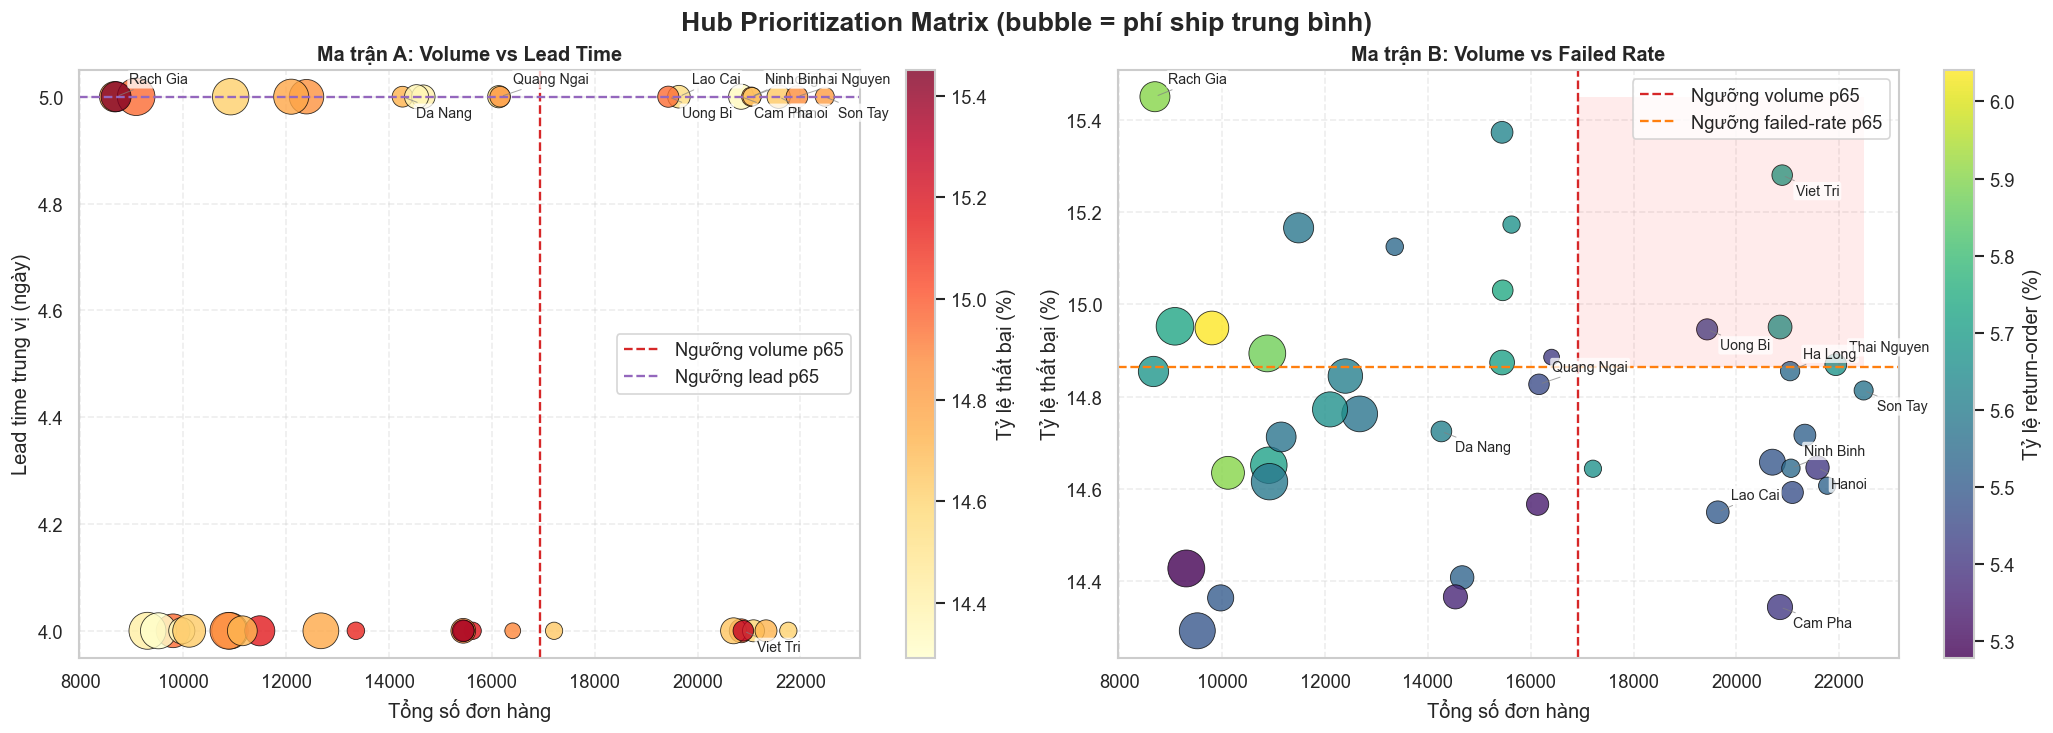

,Vùng,Thành phố,Tổng đơn,Lead trung vị (ngày),Failed rate (%),Return-order rate (%),Phí ship trung bình,Điểm ưu tiên
23,East,Thai Nguyen,21931,5.00,14.87,5.68,4.83,0.80
22,East,Son Tay,22473,5.00,14.81,5.57,4.74,0.78
15,East,Ha Long,21043,5.00,14.86,5.55,4.75,0.75
17,East,Hanoi,21576,5.00,14.65,5.41,4.89,0.71
20,East,Ninh Binh,21059,5.00,14.64,5.55,4.72,0.71
24,East,Uong Bi,19430,5.00,14.95,5.43,4.81,0.70
18,East,Lao Cai,19637,5.00,14.55,5.50,4.86,0.65
14,East,Cam Pha,20846,5.00,14.34,5.41,4.96,0.64
25,East,Viet Tri,20889,4.00,15.28,5.71,4.79,0.59
12,East,Bac Giang,20848,4.00,14.95,5.68,4.91,0.53


In [278]:
# Bước 2 - Ma trận ưu tiên trung tâm trung chuyển ở cấp city
plot_df = city_mart_filtered_df.copy()

fee_min = plot_df['avg_shipping_fee'].min()
fee_max = plot_df['avg_shipping_fee'].max()
if fee_max == fee_min:
    plot_df['bubble_size'] = 220
else:
    plot_df['bubble_size'] = 90 + (plot_df['avg_shipping_fee'] - fee_min) / (fee_max - fee_min) * 420

label_df = plot_df.sort_values('priority_score', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)

# Matrix A: Volume vs Lead Time
ax = axes[0]
sc1 = ax.scatter(
    plot_df['total_orders'],
    plot_df['median_lead_days'],
    s=plot_df['bubble_size'],
    c=plot_df['failed_rate_pct'],
    cmap='YlOrRd',
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
)

ax.axvline(vol_threshold, color='tab:red', linestyle='--', linewidth=1.4, label='Ngưỡng volume p65')
ax.axhline(lead_threshold, color='tab:purple', linestyle='--', linewidth=1.4, label='Ngưỡng lead p65')

xmax = plot_df['total_orders'].max()
ymax = plot_df['median_lead_days'].max()
ax.add_patch(Rectangle((vol_threshold, lead_threshold), xmax - vol_threshold, ymax - lead_threshold,
                       facecolor='red', alpha=0.08, edgecolor='none'))

for i, (_, row) in enumerate(label_df.iterrows()):
    ax.annotate(
        row['city'],
        (row['total_orders'], row['median_lead_days']),
        xytext=(8, 8 if i % 2 == 0 else -12),
        textcoords='offset points',
        fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.7),
    )

ax.set_title('Ma trận A: Volume vs Lead Time')
ax.set_xlabel('Tổng số đơn hàng')
ax.set_ylabel('Lead time trung vị (ngày)')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='center right')

cbar1 = fig.colorbar(sc1, ax=ax, fraction=0.046, pad=0.02)
cbar1.set_label('Tỷ lệ thất bại (%)')

# Matrix B: Volume vs Failed Rate
ax = axes[1]
sc2 = ax.scatter(
    plot_df['total_orders'],
    plot_df['failed_rate_pct'],
    s=plot_df['bubble_size'],
    c=plot_df['return_rate_pct'],
    cmap='viridis',
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
)

ax.axvline(vol_threshold, color='tab:red', linestyle='--', linewidth=1.4, label='Ngưỡng volume p65')
ax.axhline(fail_threshold, color='tab:orange', linestyle='--', linewidth=1.4, label='Ngưỡng failed-rate p65')

ymax2 = plot_df['failed_rate_pct'].max()
ax.add_patch(Rectangle((vol_threshold, fail_threshold), xmax - vol_threshold, ymax2 - fail_threshold,
                       facecolor='red', alpha=0.08, edgecolor='none'))

for i, (_, row) in enumerate(label_df.iterrows()):
    ax.annotate(
        row['city'],
        (row['total_orders'], row['failed_rate_pct']),
        xytext=(8, 8 if i % 2 == 0 else -12),
        textcoords='offset points',
        fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.7),
    )

ax.set_title('Ma trận B: Volume vs Failed Rate')
ax.set_xlabel('Tổng số đơn hàng')
ax.set_ylabel('Tỷ lệ thất bại (%)')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='upper right')

cbar2 = fig.colorbar(sc2, ax=ax, fraction=0.046, pad=0.02)
cbar2.set_label('Tỷ lệ return-order (%)')

fig.suptitle('Hub Prioritization Matrix (bubble = phí ship trung bình)', fontsize=16, fontweight='bold')
plt.show()

display(
    plot_df[
        plot_df['red_zone_lead'] | plot_df['red_zone_fail']
    ].sort_values('priority_score', ascending=False)[
        [
            'region', 'city', 'total_orders', 'median_lead_days',
            'failed_rate_pct', 'return_rate_pct', 'avg_shipping_fee', 'priority_score'
        ]
    ].rename(columns={
        'region': 'Vùng',
        'city': 'Thành phố',
        'total_orders': 'Tổng đơn',
        'median_lead_days': 'Lead trung vị (ngày)',
        'failed_rate_pct': 'Failed rate (%)',
        'return_rate_pct': 'Return-order rate (%)',
        'avg_shipping_fee': 'Phí ship trung bình',
        'priority_score': 'Điểm ưu tiên',
    })
)


In [273]:
# Bước 3 - Mô phỏng chi phí cơ hội và ROI khi ép lead time về <= 2 ngày
sim_df = hub_base_df.copy()
sim_df = sim_df[(sim_df['shipment_available']) & (sim_df['lead_time_valid'].notna())].copy()
sim_df = sim_df[sim_df['order_status'].isin(['delivered', 'returned'])].copy()

sim_df['is_failed_ship'] = sim_df['order_status'].eq('returned')
sim_df['pay_group'] = np.where(sim_df['payment_method'].eq('cod'), 'COD', 'Prepaid/Other')
sim_df['fee_bin'] = pd.cut(
    sim_df['shipping_fee'],
    bins=[-0.01, 0, 1.5, 3, np.inf],
    labels=['Miễn phí', 'Thấp (0-1.5)', 'Trung bình (1.5-3)', 'Cao (>3)'],
)

baseline_seg_df = sim_df[sim_df['lead_time_valid'] <= 2].groupby(['pay_group', 'fee_bin'], as_index=False).agg(
    baseline_fail_rate=('is_failed_ship', 'mean')
)
global_baseline = sim_df.loc[sim_df['lead_time_valid'] <= 2, 'is_failed_ship'].mean()
if pd.isna(global_baseline):
    global_baseline = sim_df['is_failed_ship'].mean()

sim_df = sim_df.merge(baseline_seg_df, on=['pay_group', 'fee_bin'], how='left')
sim_df['baseline_fail_rate'] = sim_df['baseline_fail_rate'].fillna(global_baseline)
sim_df['is_over_2d'] = sim_df['lead_time_valid'] > 2

candidate_city_df = city_mart_filtered_df[
    city_mart_filtered_df['red_zone_lead'] | city_mart_filtered_df['red_zone_fail']
].copy()

city_refund_map = sim_df[sim_df['is_failed_ship']].groupby('city')['refund_amount'].mean().fillna(0)

roi_rows = []
for city_name in candidate_city_df['city']:
    city_slice = sim_df[(sim_df['city'] == city_name) & (sim_df['is_over_2d'])].copy()
    if len(city_slice) == 0:
        continue

    observed_failed_orders = city_slice['is_failed_ship'].sum()
    expected_failed_post_hub = city_slice['baseline_fail_rate'].sum()
    prevented_failed_orders = max(0.0, observed_failed_orders - expected_failed_post_hub)

    at_risk_orders_gt2d = len(city_slice)
    observed_fail_rate = observed_failed_orders / at_risk_orders_gt2d
    baseline_fail_rate = city_slice['baseline_fail_rate'].mean()

    gmv_at_risk_vnd = city_slice['payment_value'].sum()
    avg_order_value_vnd = gmv_at_risk_vnd / at_risk_orders_gt2d if at_risk_orders_gt2d > 0 else 0
    salvaged_revenue_vnd = prevented_failed_orders * avg_order_value_vnd

    avg_refund_failed_order_vnd = float(city_refund_map.get(city_name, 0.0))
    refund_saved_vnd_est = prevented_failed_orders * avg_refund_failed_order_vnd

    roi_rows.append({
        'city': city_name,
        'at_risk_orders_gt2d': at_risk_orders_gt2d,
        'observed_fail_rate_gt2d': observed_fail_rate,
        'baseline_fail_rate_2d': baseline_fail_rate,
        'prevented_failed_orders_est': prevented_failed_orders,
        'gmv_at_risk_vnd': gmv_at_risk_vnd,
        'salvaged_revenue_vnd_est': max(0.0, salvaged_revenue_vnd),
        'refund_saved_vnd_est': max(0.0, refund_saved_vnd_est),
    })

roi_df = pd.DataFrame(roi_rows)
hub_rank_df = candidate_city_df.merge(roi_df, on='city', how='left').fillna(0)

for score_col in ['salvaged_revenue_vnd_est', 'refund_saved_vnd_est']:
    vmin = hub_rank_df[score_col].min()
    vmax = hub_rank_df[score_col].max()
    if vmax == vmin:
        hub_rank_df[f'{score_col}_score'] = 0.0
    else:
        hub_rank_df[f'{score_col}_score'] = (hub_rank_df[score_col] - vmin) / (vmax - vmin)

hub_rank_df['roi_score'] = (
    0.75 * hub_rank_df['salvaged_revenue_vnd_est_score'] +
    0.25 * hub_rank_df['refund_saved_vnd_est_score']
)

hub_rank_df['final_score'] = 0.60 * hub_rank_df['priority_score'] + 0.40 * hub_rank_df['roi_score']

top_hub_df = hub_rank_df.sort_values('final_score', ascending=False).head(5).copy()

portfolio_impact_df = pd.DataFrame({
    'metric': [
        'Số thành phố vùng đỏ được đánh giá',
        'Tổng đơn at-risk > 2 ngày (Top 5)',
        'Số đơn thất bại có thể giảm (ước tính)',
        'Doanh thu có thể cứu vãn (VND ước tính)',
        'Giá trị hoàn tiền có thể tránh (VND ước tính)',
    ],
    'value': [
        len(candidate_city_df),
        int(top_hub_df['at_risk_orders_gt2d'].sum()),
        round(top_hub_df['prevented_failed_orders_est'].sum(), 2),
        round(top_hub_df['salvaged_revenue_vnd_est'].sum(), 0),
        round(top_hub_df['refund_saved_vnd_est'].sum(), 0),
    ]
})

print('Tỷ lệ thất bại cơ sở (lead <= 2 ngày) theo phân khúc thanh toán + phí:')
display(
    baseline_seg_df.sort_values(['pay_group', 'fee_bin']).rename(columns={
        'pay_group': 'Nhóm thanh toán',
        'fee_bin': 'Mức phí',
        'baseline_fail_rate': 'Tỷ lệ thất bại cơ sở',
    })
)

print('Xếp hạng thành phố đề xuất mở hub:')
display(
    top_hub_df[[
        'region', 'city', 'total_orders', 'median_lead_days', 'failed_rate_pct',
        'at_risk_orders_gt2d', 'prevented_failed_orders_est',
        'salvaged_revenue_vnd_est', 'refund_saved_vnd_est',
        'priority_score', 'roi_score', 'final_score'
    ]].rename(columns={
        'region': 'Vùng',
        'city': 'Thành phố',
        'total_orders': 'Tổng đơn',
        'median_lead_days': 'Lead trung vị (ngày)',
        'failed_rate_pct': 'Failed rate (%)',
        'at_risk_orders_gt2d': 'Đơn at-risk > 2 ngày',
        'prevented_failed_orders_est': 'Số đơn thất bại giảm (ước tính)',
        'salvaged_revenue_vnd_est': 'Doanh thu cứu vãn (VND)',
        'refund_saved_vnd_est': 'Hoàn tiền tránh được (VND)',
        'priority_score': 'Điểm ưu tiên',
        'roi_score': 'Điểm ROI',
        'final_score': 'Điểm cuối',
    })
)

print('Tác động danh mục (Top 5):')
portfolio_impact_df


Tỷ lệ thất bại cơ sở (lead <= 2 ngày) theo phân khúc thanh toán + phí:


,Nhóm thanh toán,Mức phí,Tỷ lệ thất bại cơ sở
0,COD,Miễn phí,0.00
1,COD,Thấp (0-1.5),0.11
2,COD,Trung bình (1.5-3),0.11
3,COD,Cao (>3),0.11
4,Prepaid/Other,Miễn phí,0.07
5,Prepaid/Other,Thấp (0-1.5),0.06
6,Prepaid/Other,Trung bình (1.5-3),0.06
7,Prepaid/Other,Cao (>3),0.06


Xếp hạng thành phố đề xuất mở hub:


,Vùng,Thành phố,Tổng đơn,Lead trung vị (ngày),Failed rate (%),Đơn at-risk > 2 ngày,Số đơn thất bại giảm (ước tính),Doanh thu cứu vãn (VND),Hoàn tiền tránh được (VND),Điểm ưu tiên,Điểm ROI,Điểm cuối
7,East,Thai Nguyen,21931,5.00,14.87,15542,23.84,587774.87,348906.37,0.80,1.00,0.88
6,East,Son Tay,22473,5.00,14.81,15952,16.24,401350.17,224986.47,0.78,0.67,0.74
9,East,Viet Tri,20889,4.00,15.28,14853,22.54,561589.08,309820.91,0.59,0.94,0.73
0,East,Bac Giang,20848,4.00,14.95,14831,14.58,358003.58,205837.93,0.53,0.60,0.56
2,East,Ha Long,21043,5.00,14.86,14955,1.96,48697.79,29055.54,0.75,0.08,0.48


Tác động danh mục (Top 5):


,metric,value
0,Số thành phố vùng đỏ được đánh giá,10.00
1,Tổng đơn at-risk > 2 ngày (Top 5),76133.00
2,Số đơn thất bại có thể giảm (ước tính),79.16
3,Doanh thu có thể cứu vãn (VND ước tính),1957415.00
4,Giá trị hoàn tiền có thể tránh (VND ước tính),1118607.00


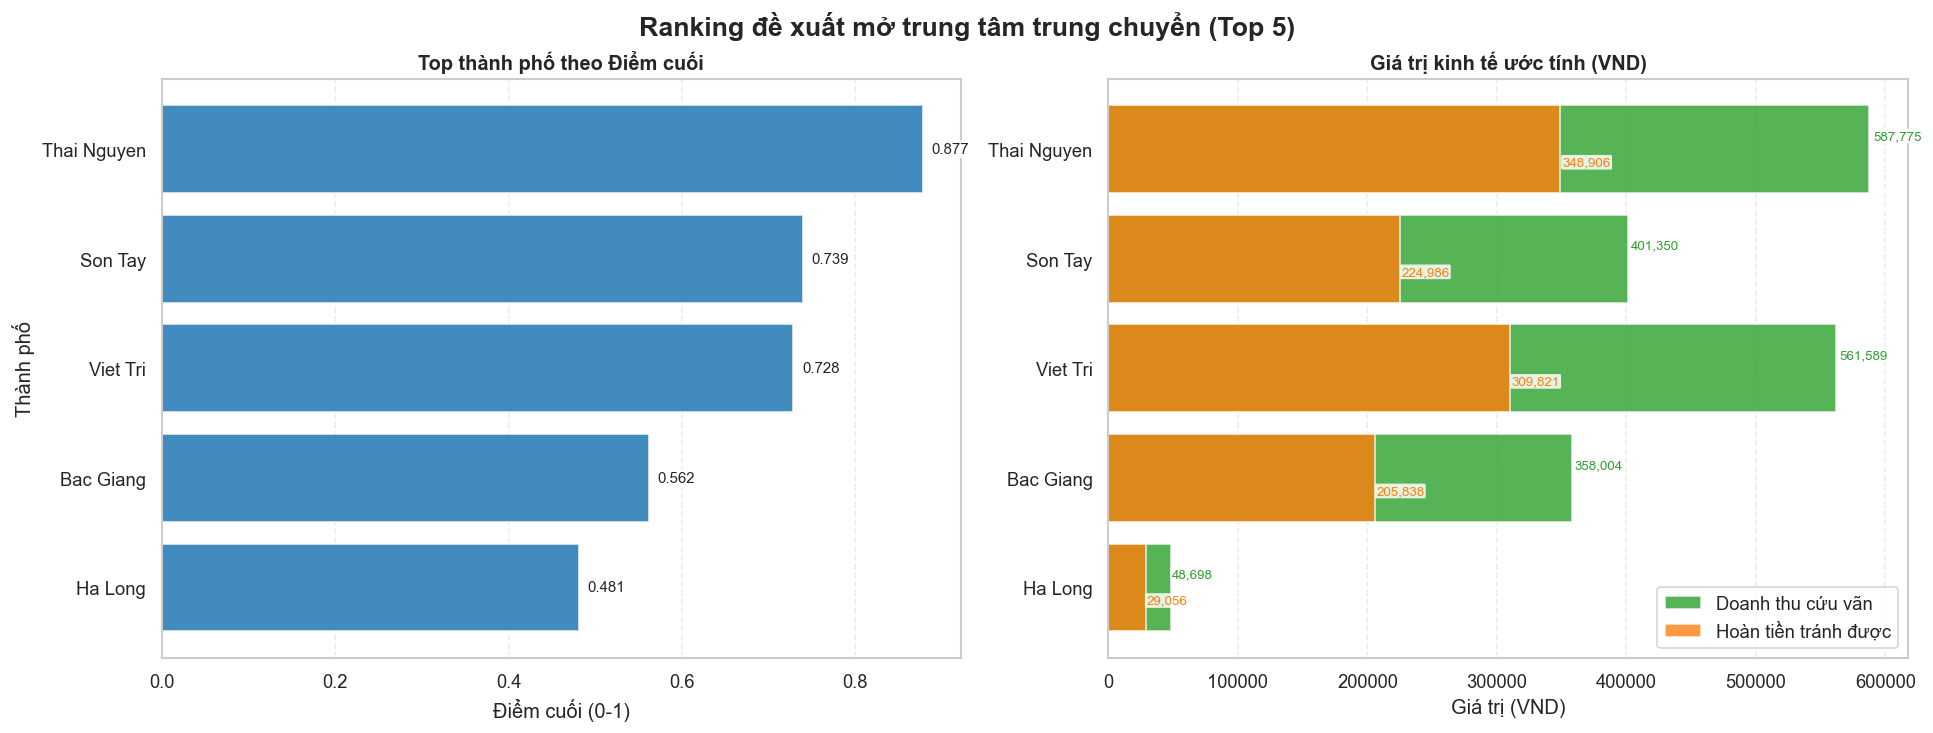

,Thành phố,Đơn at-risk > 2 ngày,Số đơn thất bại giảm (ước tính),Doanh thu cứu vãn (VND),Hoàn tiền tránh được (VND),Điểm cuối
7,Thai Nguyen,15542,23.84,587774.87,348906.37,0.88
6,Son Tay,15952,16.24,401350.17,224986.47,0.74
9,Viet Tri,14853,22.54,561589.08,309820.91,0.73
0,Bac Giang,14831,14.58,358003.58,205837.93,0.56
2,Ha Long,14955,1.96,48697.79,29055.54,0.48


In [274]:
# Bước 4 - Trực quan hóa bảng xếp hạng thành phố mở hub
rank_plot_df = top_hub_df.sort_values('final_score', ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Xếp hạng theo điểm cuối
axes[0].barh(rank_plot_df['city'], rank_plot_df['final_score'], color='tab:blue', alpha=0.85)
axes[0].set_title('Top thành phố theo Điểm cuối')
axes[0].set_xlabel('Điểm cuối (0-1)')
axes[0].set_ylabel('Thành phố')
axes[0].grid(False)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.35)

for i, v in enumerate(rank_plot_df['final_score']):
    axes[0].text(
        v + 0.01,
        i,
        f'{v:.3f}',
        va='center',
        fontsize=9,
        zorder=6,
        bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.9),
    )

# So sánh giá trị kinh tế
axes[1].barh(rank_plot_df['city'], rank_plot_df['salvaged_revenue_vnd_est'],
             color='tab:green', alpha=0.8, label='Doanh thu cứu vãn')
axes[1].barh(rank_plot_df['city'], rank_plot_df['refund_saved_vnd_est'],
             color='tab:orange', alpha=0.8, label='Hoàn tiền tránh được')
axes[1].set_title('Giá trị kinh tế ước tính (VND)')
axes[1].set_xlabel('Giá trị (VND)')
axes[1].grid(False)
axes[1].grid(True, axis='x', linestyle='--', alpha=0.35)
axes[1].legend(loc='lower right')

for i, v in enumerate(rank_plot_df['salvaged_revenue_vnd_est']):
    axes[1].text(
        v * 1.005 + 1,
        i + 0.12,
        f'{v:,.0f}',
        va='center',
        fontsize=8,
        color='tab:green',
        zorder=6,
        bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.85),
    )
for i, v in enumerate(rank_plot_df['refund_saved_vnd_est']):
    axes[1].text(
        v * 1.005 + 1,
        i - 0.12,
        f'{v:,.0f}',
        va='center',
        fontsize=8,
        color='tab:orange',
        zorder=6,
        bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.85),
    )

fig.suptitle('Ranking đề xuất mở trung tâm trung chuyển (Top 5)', fontsize=16, fontweight='bold')
plt.show()

display(
    top_hub_df[[
        'city', 'at_risk_orders_gt2d', 'prevented_failed_orders_est',
        'salvaged_revenue_vnd_est', 'refund_saved_vnd_est', 'final_score'
    ]].sort_values('final_score', ascending=False).rename(columns={
        'city': 'Thành phố',
        'at_risk_orders_gt2d': 'Đơn at-risk > 2 ngày',
        'prevented_failed_orders_est': 'Số đơn thất bại giảm (ước tính)',
        'salvaged_revenue_vnd_est': 'Doanh thu cứu vãn (VND)',
        'refund_saved_vnd_est': 'Hoàn tiền tránh được (VND)',
        'final_score': 'Điểm cuối',
    })
)


**Nhận xét hợp nhất Mục 8 (theo plan mới):**

- **Kết luận chính:** Cụm thành phố volume cao nhưng lead/fail cao đã được định lượng rõ bằng ma trận ưu tiên và điểm `final_score`.
- **Giá trị kinh tế:** Mô phỏng cho thấy giảm lead về mốc <=2 ngày có thể cắt giảm số đơn thất bại và đồng thời giảm phần hoàn tiền phải chi.
- **Khoanh vùng vi mô:** Sau khi chọn city trọng điểm, cần drill-down tiếp xuống `district` và `zip` để chốt vị trí hub tránh quyết định quá vĩ mô.
- **Lưu ý mô hình:** ROI hiện là mô phỏng kỹ thuật trên dữ liệu lịch sử; để ra quyết định đầu tư thực tế cần bổ sung CapEx/OpEx và ràng buộc năng lực kho.


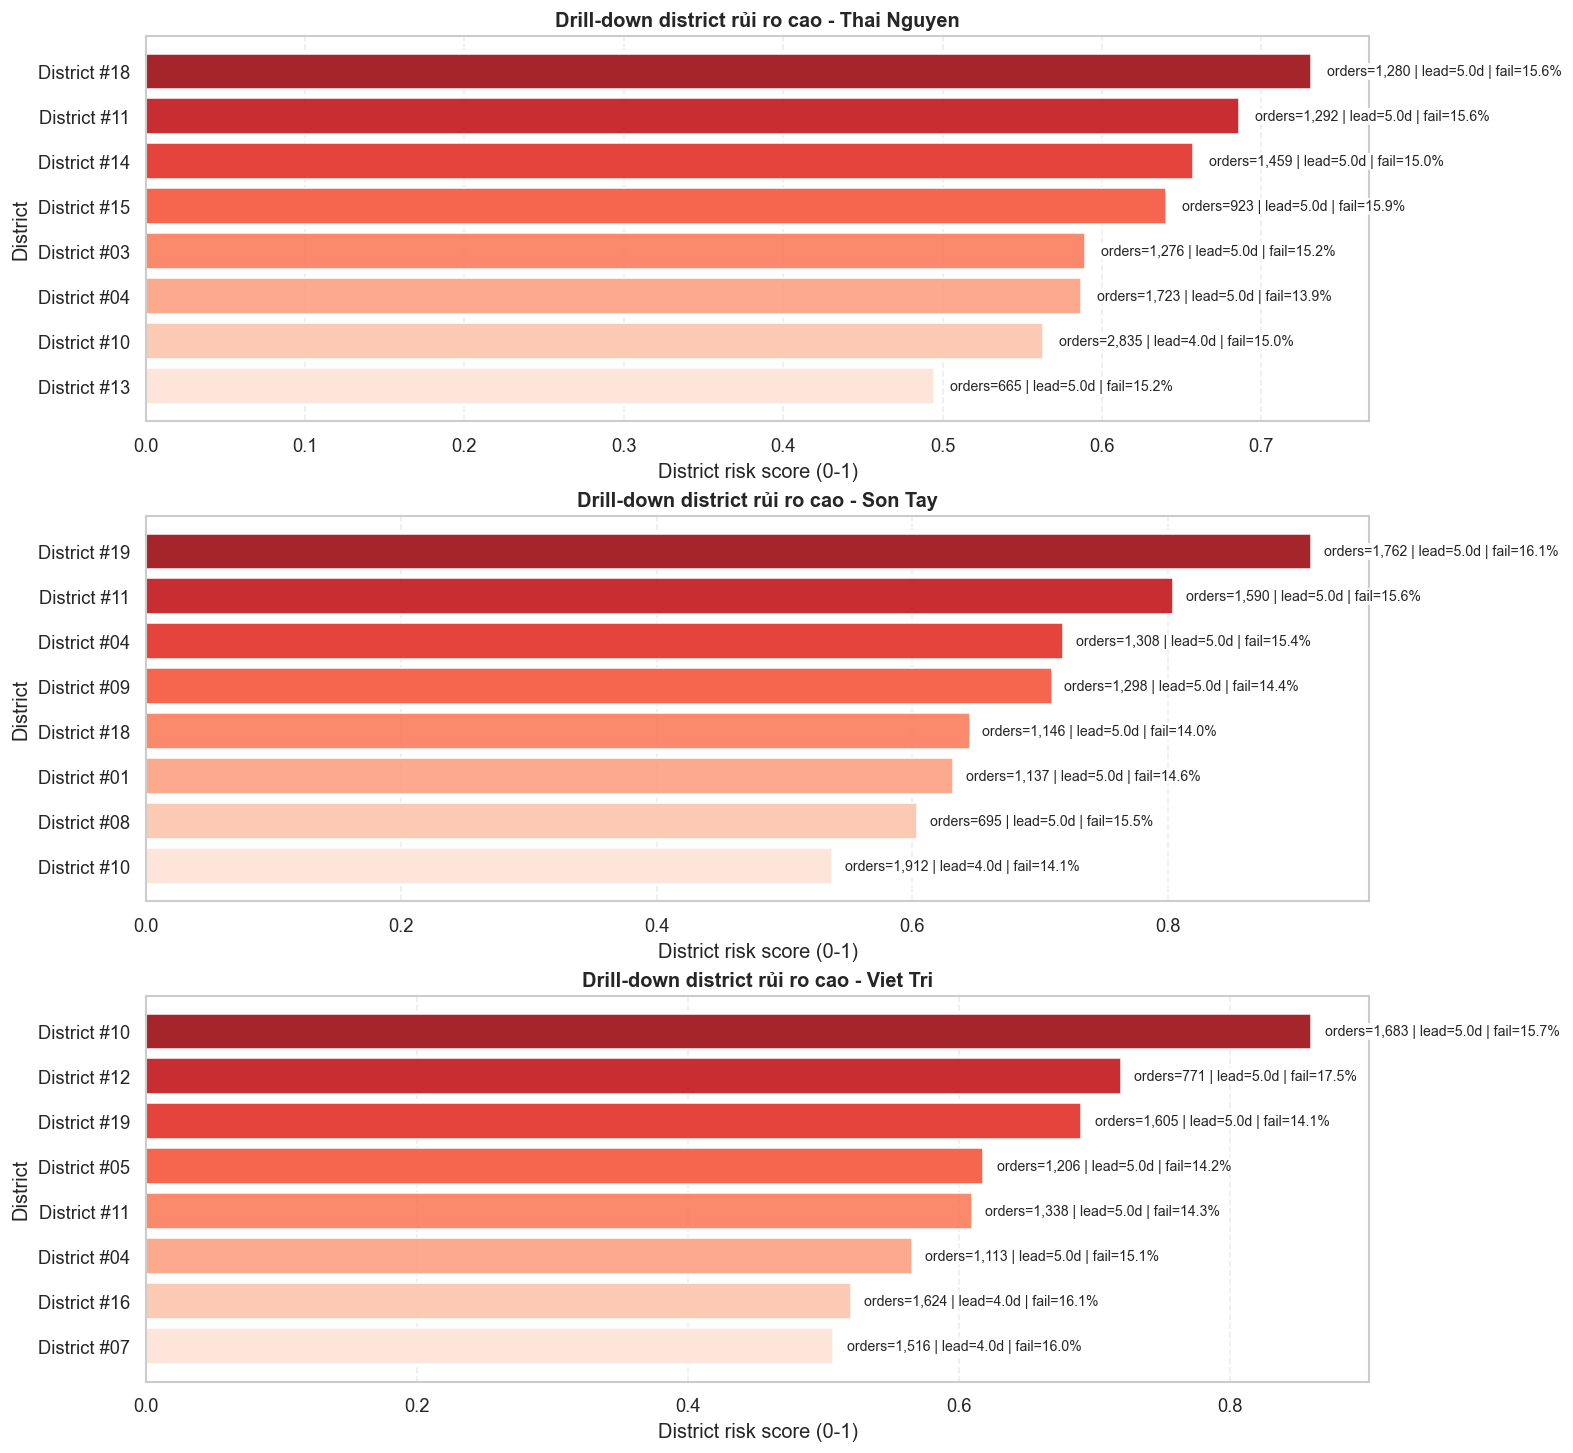

,Thành phố,Quận/Huyện,Tổng đơn,Lead trung vị (ngày),Lead p90 (ngày),Failed rate (%),Return-order rate (%),Điểm rủi ro district
18,Son Tay,District #19,1762,5.00,7.00,16.12,6.24,0.91
10,Son Tay,District #11,1590,5.00,7.00,15.60,5.41,0.80
3,Son Tay,District #04,1308,5.00,7.00,15.44,5.43,0.72
8,Son Tay,District #09,1298,5.00,7.00,14.41,6.39,0.71
17,Son Tay,District #18,1146,5.00,7.00,14.05,6.28,0.64
0,Son Tay,District #01,1137,5.00,7.00,14.60,5.45,0.63
7,Son Tay,District #08,695,5.00,7.00,15.54,6.76,0.60
9,Son Tay,District #10,1912,4.00,7.00,14.12,5.60,0.54
36,Thai Nguyen,District #18,1280,5.00,7.00,15.62,6.80,0.73
29,Thai Nguyen,District #11,1292,5.00,7.00,15.63,6.04,0.69


In [275]:
# Bước 5 - Drill-down city -> district để xác định cụm quận/huyện ách tắc
focus_cities = top_hub_df.sort_values('final_score', ascending=False)['city'].head(3).tolist()
DISTRICT_MIN_ORDERS = 120

city_district_df = hub_base_df[hub_base_df['city'].isin(focus_cities)].copy()
district_mart_df = city_district_df.groupby(['city', 'district'], as_index=False).agg(
    total_orders=('order_id', 'count'),
    shipment_orders=('shipment_available', 'sum'),
    median_lead_days=('lead_time_valid', 'median'),
    p90_lead_days=('lead_time_valid', lambda x: x.quantile(0.9)),
    failed_rate_pct=('is_failed_order', lambda x: x.mean() * 100),
    return_rate_pct=('is_return_order', lambda x: x.mean() * 100),
    avg_shipping_fee=('shipping_fee', 'mean'),
    avg_refund_vnd=('refund_amount', 'mean'),
)

district_mart_df = district_mart_df[district_mart_df['total_orders'] >= DISTRICT_MIN_ORDERS].copy()

for col in ['median_lead_days', 'p90_lead_days', 'avg_shipping_fee', 'avg_refund_vnd']:
    district_mart_df[col] = district_mart_df[col].fillna(district_mart_df[col].median())

for col in ['total_orders', 'median_lead_days', 'failed_rate_pct', 'return_rate_pct']:
    district_mart_df[f'{col}_norm'] = district_mart_df.groupby('city')[col].transform(
        lambda x: 0.5 if x.max() == x.min() else (x - x.min()) / (x.max() - x.min())
    )

district_mart_df['district_risk_score'] = (
    0.35 * district_mart_df['total_orders_norm'] +
    0.30 * district_mart_df['median_lead_days_norm'] +
    0.20 * district_mart_df['failed_rate_pct_norm'] +
    0.15 * district_mart_df['return_rate_pct_norm']
)

top_district_df = district_mart_df.sort_values(['city', 'district_risk_score'], ascending=[True, False]).groupby('city').head(8)

fig, axes = plt.subplots(len(focus_cities), 1, figsize=(13, 4 * len(focus_cities)), constrained_layout=True)
if len(focus_cities) == 1:
    axes = [axes]

for ax, city_name in zip(axes, focus_cities):
    temp = top_district_df[top_district_df['city'] == city_name].sort_values('district_risk_score', ascending=True)
    colors = sns.color_palette('Reds', n_colors=len(temp))
    bars = ax.barh(temp['district'], temp['district_risk_score'], color=colors, alpha=0.9)

    for bar, (_, row) in zip(bars, temp.iterrows()):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"orders={int(row['total_orders']):,} | lead={row['median_lead_days']:.1f}d | fail={row['failed_rate_pct']:.1f}%",
            va='center',
            fontsize=8.5,
            zorder=6,
            bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.85),
        )

    ax.set_title(f'Drill-down district rủi ro cao - {city_name}', fontweight='bold')
    ax.set_xlabel('District risk score (0-1)')
    ax.set_ylabel('District')
    ax.grid(False)
    ax.grid(True, axis='x', linestyle='--', alpha=0.35)

plt.show()

display(
    top_district_df[[
        'city', 'district', 'total_orders', 'median_lead_days', 'p90_lead_days',
        'failed_rate_pct', 'return_rate_pct', 'district_risk_score'
    ]].rename(columns={
        'city': 'Thành phố',
        'district': 'Quận/Huyện',
        'total_orders': 'Tổng đơn',
        'median_lead_days': 'Lead trung vị (ngày)',
        'p90_lead_days': 'Lead p90 (ngày)',
        'failed_rate_pct': 'Failed rate (%)',
        'return_rate_pct': 'Return-order rate (%)',
        'district_risk_score': 'Điểm rủi ro district',
    }).sort_values(['Thành phố', 'Điểm rủi ro district'], ascending=[True, False])
)


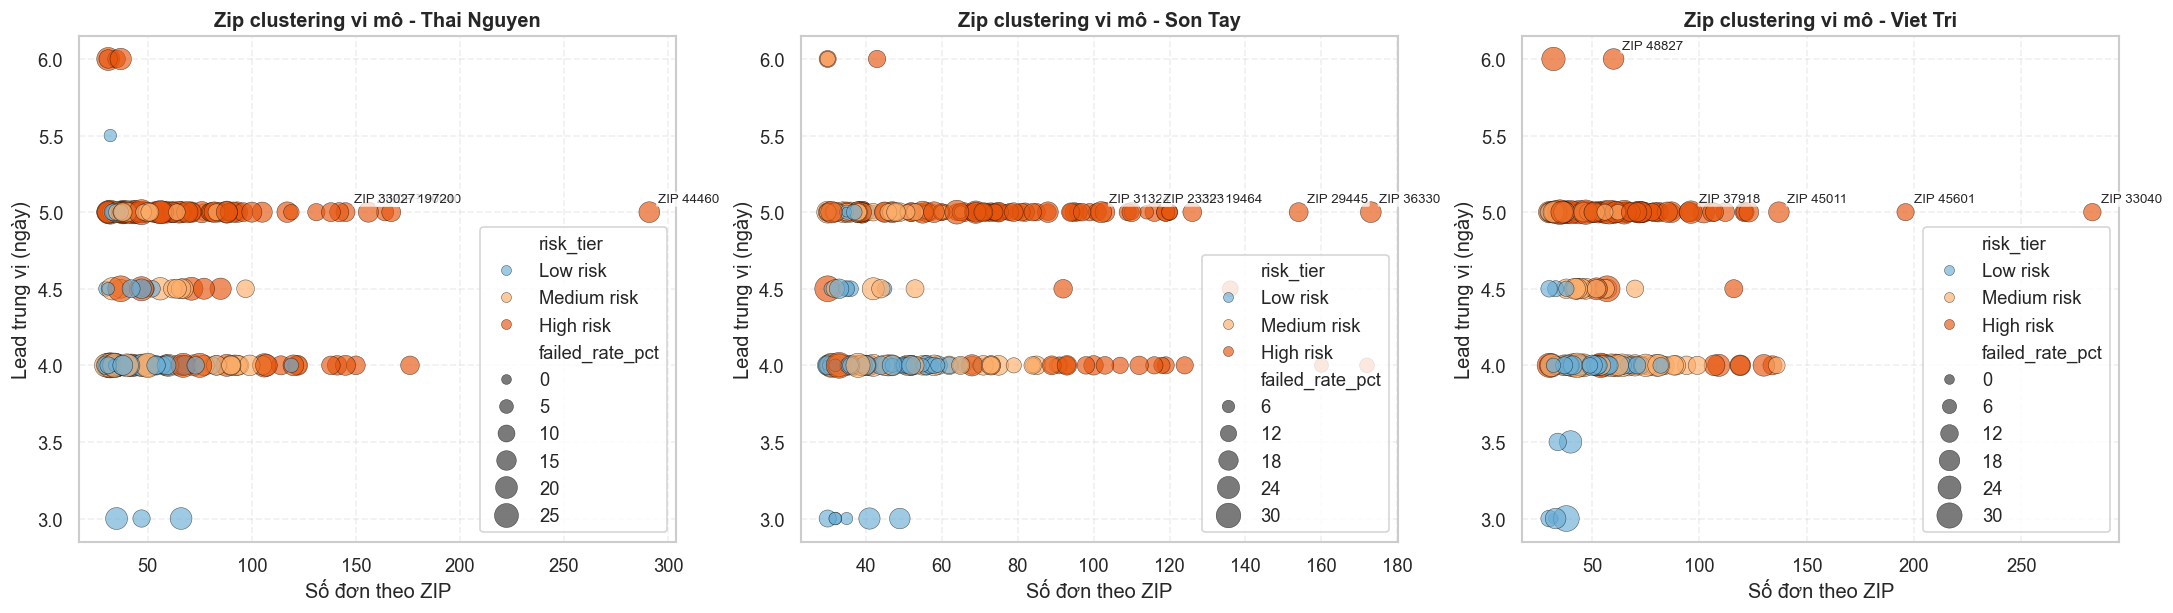

,Thành phố,Quận/Huyện,ZIP,Tổng đơn,Lead trung vị (ngày),Lead p90 (ngày),Failed rate (%),Return-order rate (%),Điểm rủi ro ZIP,Cụm vi mô
483,Son Tay,District #09,36330,173,5.00,7.00,20.81,10.98,0.78,High density | High risk
567,Son Tay,District #11,29445,154,5.00,7.00,16.88,5.19,0.67,High density | High risk
251,Son Tay,District #04,19464,126,5.00,7.00,16.67,7.94,0.60,High density | High risk
598,Son Tay,District #11,31324,102,5.00,7.00,21.57,10.78,0.58,High density | High risk
373,Son Tay,District #07,23323,116,5.00,7.00,16.38,6.90,0.57,High density | High risk
697,Son Tay,District #14,43551,119,5.00,7.00,15.97,5.04,0.56,High density | High risk
755,Son Tay,District #15,43130,172,4.00,7.00,9.30,4.07,0.56,High density | High risk
952,Son Tay,District #19,37087,110,5.00,7.00,17.27,6.36,0.55,High density | High risk
570,Son Tay,District #11,29485,119,5.00,7.00,15.13,4.20,0.55,High density | High risk
870,Son Tay,District #18,48044,120,5.00,7.00,10.83,6.67,0.54,High density | High risk


In [276]:
# Bước 6 - Drill-down district -> zip, gom cụm vi mô mã bưu chính
ZIP_MIN_ORDERS = 30

zip_mart_df = city_district_df.groupby(['city', 'district', 'zip'], as_index=False).agg(
    total_orders=('order_id', 'count'),
    median_lead_days=('lead_time_valid', 'median'),
    p90_lead_days=('lead_time_valid', lambda x: x.quantile(0.9)),
    failed_rate_pct=('is_failed_order', lambda x: x.mean() * 100),
    return_rate_pct=('is_return_order', lambda x: x.mean() * 100),
    avg_shipping_fee=('shipping_fee', 'mean'),
    avg_refund_vnd=('refund_amount', 'mean'),
)

zip_mart_df = zip_mart_df[zip_mart_df['total_orders'] >= ZIP_MIN_ORDERS].copy()
for col in ['median_lead_days', 'p90_lead_days', 'avg_shipping_fee', 'avg_refund_vnd']:
    zip_mart_df[col] = zip_mart_df[col].fillna(zip_mart_df[col].median())

for col in ['total_orders', 'median_lead_days', 'failed_rate_pct', 'return_rate_pct']:
    zip_mart_df[f'{col}_norm'] = zip_mart_df.groupby('city')[col].transform(
        lambda x: 0.5 if x.max() == x.min() else (x - x.min()) / (x.max() - x.min())
    )

zip_mart_df['zip_risk_score'] = (
    0.40 * zip_mart_df['total_orders_norm'] +
    0.30 * zip_mart_df['median_lead_days_norm'] +
    0.20 * zip_mart_df['failed_rate_pct_norm'] +
    0.10 * zip_mart_df['return_rate_pct_norm']
)

# Gom cụm vi mô bằng tiers theo mật độ đơn và mức rủi ro
zip_mart_df['density_tier'] = zip_mart_df.groupby('city')['total_orders'].transform(
    lambda x: pd.qcut(x.rank(method='first'), q=3, labels=['Low density', 'Medium density', 'High density'])
)
zip_mart_df['risk_tier'] = zip_mart_df.groupby('city')['zip_risk_score'].transform(
    lambda x: pd.qcut(x.rank(method='first'), q=3, labels=['Low risk', 'Medium risk', 'High risk'])
)
zip_mart_df['micro_cluster'] = zip_mart_df['density_tier'].astype(str) + ' | ' + zip_mart_df['risk_tier'].astype(str)
zip_mart_df['is_micro_hub_candidate'] = (
    zip_mart_df['density_tier'].astype(str).eq('High density') &
    zip_mart_df['risk_tier'].astype(str).eq('High risk')
)

top_zip_df = zip_mart_df[zip_mart_df['is_micro_hub_candidate']].copy()
top_zip_df = top_zip_df.sort_values(['city', 'zip_risk_score'], ascending=[True, False]).groupby('city').head(10)

fig, axes = plt.subplots(1, len(focus_cities), figsize=(6 * len(focus_cities), 5), sharey=False, constrained_layout=True)
if len(focus_cities) == 1:
    axes = [axes]

risk_palette = {'Low risk': '#6BAED6', 'Medium risk': '#FDAE6B', 'High risk': '#E6550D'}

for ax, city_name in zip(axes, focus_cities):
    temp = zip_mart_df[zip_mart_df['city'] == city_name].copy()
    sns.scatterplot(
        data=temp,
        x='total_orders',
        y='median_lead_days',
        hue='risk_tier',
        hue_order=['Low risk', 'Medium risk', 'High risk'],
        palette=risk_palette,
        size='failed_rate_pct',
        sizes=(35, 240),
        alpha=0.65,
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
    )

    highlight = top_zip_df[top_zip_df['city'] == city_name].head(5)
    for _, row in highlight.iterrows():
        ax.annotate(
            f"ZIP {int(row['zip'])}",
            (row['total_orders'], row['median_lead_days']),
            xytext=(5, 6),
            textcoords='offset points',
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.75),
        )

    ax.set_title(f'Zip clustering vi mô - {city_name}', fontweight='bold')
    ax.set_xlabel('Số đơn theo ZIP')
    ax.set_ylabel('Lead trung vị (ngày)')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.show()

display(
    top_zip_df[[
        'city', 'district', 'zip', 'total_orders', 'median_lead_days', 'p90_lead_days',
        'failed_rate_pct', 'return_rate_pct', 'zip_risk_score', 'micro_cluster'
    ]].rename(columns={
        'city': 'Thành phố',
        'district': 'Quận/Huyện',
        'zip': 'ZIP',
        'total_orders': 'Tổng đơn',
        'median_lead_days': 'Lead trung vị (ngày)',
        'p90_lead_days': 'Lead p90 (ngày)',
        'failed_rate_pct': 'Failed rate (%)',
        'return_rate_pct': 'Return-order rate (%)',
        'zip_risk_score': 'Điểm rủi ro ZIP',
        'micro_cluster': 'Cụm vi mô',
    }).sort_values(['Thành phố', 'Điểm rủi ro ZIP'], ascending=[True, False])
)


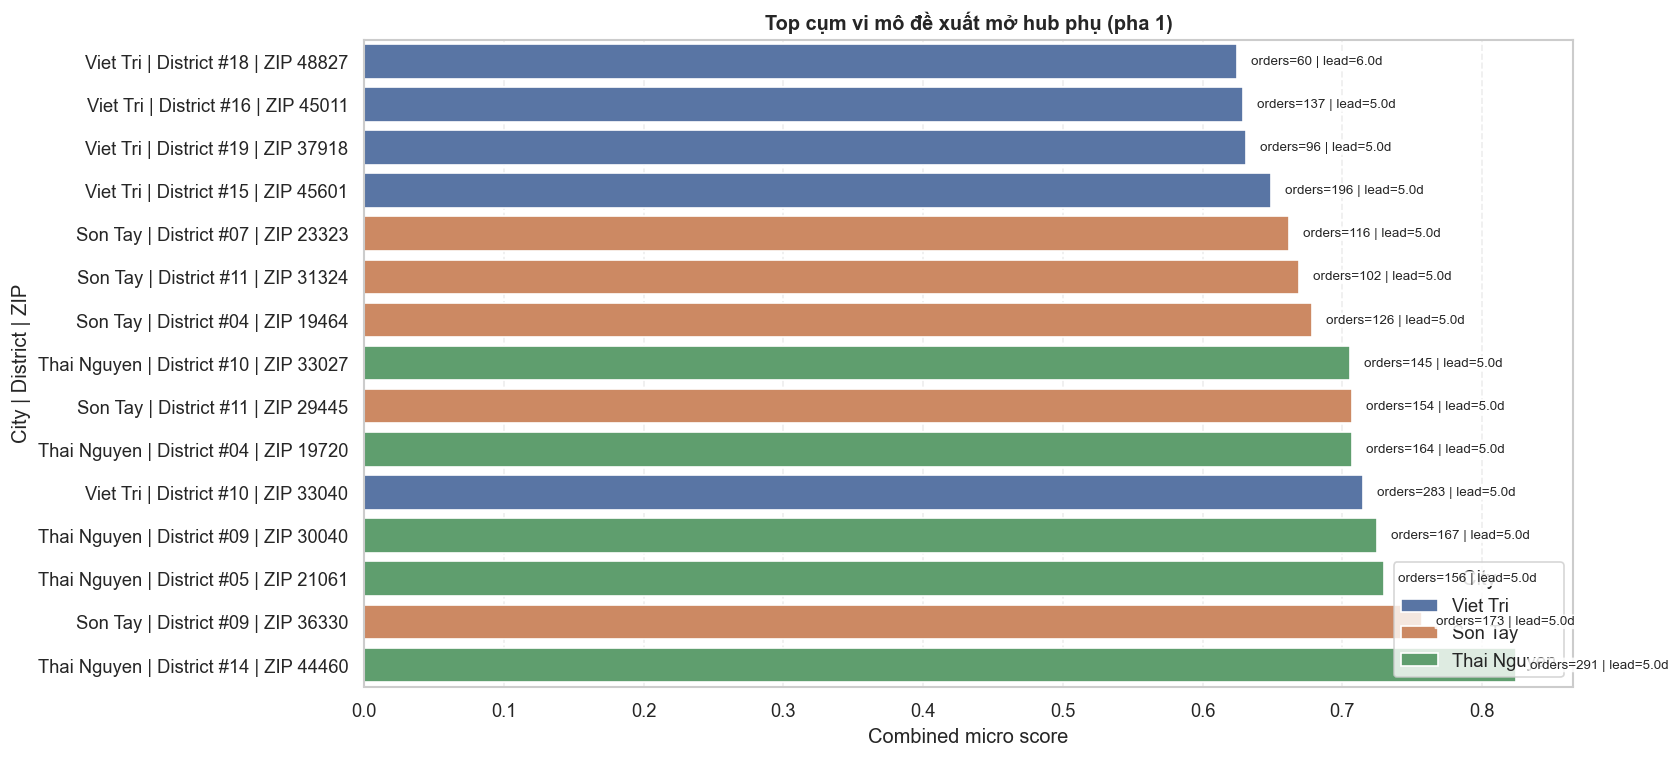

Bảng shortlist vi mô cho triển khai pha 1:


,Vùng,Thành phố,Quận/Huyện,ZIP,Tổng đơn,Lead trung vị (ngày),Failed rate (%),Return-order rate (%),Điểm rủi ro ZIP,Điểm vi mô tổng hợp
10,East,Thai Nguyen,District #14,44460,291,5.00,17.53,7.56,0.76,0.82
0,East,Son Tay,District #09,36330,173,5.00,20.81,10.98,0.78,0.76
11,East,Thai Nguyen,District #05,21061,156,5.00,16.03,8.97,0.55,0.73
12,East,Thai Nguyen,District #09,30040,167,5.00,13.77,6.59,0.54,0.72
20,East,Viet Tri,District #10,33040,283,5.00,11.66,4.95,0.70,0.71
13,East,Thai Nguyen,District #04,19720,164,5.00,10.98,3.66,0.50,0.71
1,East,Son Tay,District #11,29445,154,5.00,16.88,5.19,0.67,0.71
14,East,Thai Nguyen,District #10,33027,145,5.00,13.79,4.83,0.49,0.71
2,East,Son Tay,District #04,19464,126,5.00,16.67,7.94,0.60,0.68
3,East,Son Tay,District #11,31324,102,5.00,21.57,10.78,0.58,0.67


KPI tóm tắt cho kế hoạch mở rộng hub:


,metric,value
0,Số thành phố trọng điểm (Top hub),5
1,Số district trọng điểm (Top 8/city),16
2,Số ZIP ứng viên vi mô (High density + High risk),30
3,Số cụm vi mô shortlist pha 1 (Top 5/city),15


In [277]:
# Bước 7 - Shortlist triển khai pha 1 (city -> district -> zip)
city_rank_short_df = top_hub_df[['city', 'region', 'final_score', 'priority_score', 'roi_score']].copy()

micro_shortlist_df = top_zip_df.merge(
    city_rank_short_df,
    on='city',
    how='left'
).copy()

micro_shortlist_df['combined_micro_score'] = (
    0.55 * micro_shortlist_df['final_score'] +
    0.45 * micro_shortlist_df['zip_risk_score']
)

micro_shortlist_df = micro_shortlist_df.sort_values('combined_micro_score', ascending=False)
phase1_df = micro_shortlist_df.groupby('city').head(5).copy()
phase1_df['micro_label'] = (
    phase1_df['city'] + ' | ' + phase1_df['district'].astype(str) + ' | ZIP ' + phase1_df['zip'].astype(int).astype(str)
)

fig, ax = plt.subplots(figsize=(13, 7))
plot_df = phase1_df.head(15).sort_values('combined_micro_score', ascending=True)
sns.barplot(
    data=plot_df,
    y='micro_label',
    x='combined_micro_score',
    hue='city',
    dodge=False,
    ax=ax,
)
ax.set_title('Top cụm vi mô đề xuất mở hub phụ (pha 1)', fontweight='bold')
ax.set_xlabel('Combined micro score')
ax.set_ylabel('City | District | ZIP')
ax.grid(False)
ax.grid(True, axis='x', linestyle='--', alpha=0.35)
ax.legend(title='City', loc='lower right')

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row['combined_micro_score'] + 0.01,
        i,
        f"orders={int(row['total_orders']):,} | lead={row['median_lead_days']:.1f}d",
        va='center',
        fontsize=8,
        zorder=6,
        bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.85),
    )

plt.show()

summary_phase1_df = pd.DataFrame({
    'metric': [
        'Số thành phố trọng điểm (Top hub)',
        'Số district trọng điểm (Top 8/city)',
        'Số ZIP ứng viên vi mô (High density + High risk)',
        'Số cụm vi mô shortlist pha 1 (Top 5/city)',
    ],
    'value': [
        int(top_hub_df['city'].nunique()),
        int(top_district_df['district'].nunique()),
        int(top_zip_df.shape[0]),
        int(phase1_df.shape[0]),
    ]
})

print('Bảng shortlist vi mô cho triển khai pha 1:')
display(
    phase1_df[[
        'region', 'city', 'district', 'zip', 'total_orders', 'median_lead_days',
        'failed_rate_pct', 'return_rate_pct', 'zip_risk_score', 'combined_micro_score'
    ]].rename(columns={
        'region': 'Vùng',
        'city': 'Thành phố',
        'district': 'Quận/Huyện',
        'zip': 'ZIP',
        'total_orders': 'Tổng đơn',
        'median_lead_days': 'Lead trung vị (ngày)',
        'failed_rate_pct': 'Failed rate (%)',
        'return_rate_pct': 'Return-order rate (%)',
        'zip_risk_score': 'Điểm rủi ro ZIP',
        'combined_micro_score': 'Điểm vi mô tổng hợp',
    }).sort_values('Điểm vi mô tổng hợp', ascending=False)
)

print('KPI tóm tắt cho kế hoạch mở rộng hub:')
summary_phase1_df


### 4. Đề xuất chiến lược mở rộng trung tâm trung chuyển (Drill-down từ City -> District -> ZIP)
**Nhận xét:**
- **Quan sát:**
  - Bảng tổng hợp Snapshot và Ma trận ưu tiên A & B đã bóc tách được các thành phố trọng điểm có lượng đơn kẹt (At-risk > 2 ngày) khổng lồ như Thái Nguyên, Sơn Tây, Việt Trì. Giá trị doanh thu có thể cứu vãn và số tiền hoàn phí có thể tránh lên đến hàng tỷ VND.
  - Quá trình Gom cụm vi mô mã bưu chính (ZIP micro-clustering) đã tinh lọc ra Top 15 khu vực "High density + High risk" (Volume rất cao, Lead trung vị = 5 ngày, Failed rate từ 16% - 26%).
- **Insights:**
  - **Mỏ vàng trong các "vùng kẹt":** Sự ách tắc logistics (Ma sát giao hàng) tại các khu vực Volume cao đang bóp nghẹt doanh thu thực tế. Việc ép Lead Time từ 5-7 ngày lùi về <= 2 ngày tại các điểm nóng này không chỉ giải quyết bài toán vận hành mà thực chất là bài toán Tăng trưởng Doanh thu ròng (Growth & Revenue Recovery).
  - **Triển khai sắc bén (Precision Expansion):** Việc mở kho trung chuyển (Hub) truyền thống theo nguyên tắc "phủ sóng" là sai lầm tốn kém. Thay vào đó, Hub cần được cắm cọc chính xác vào ranh giới của các cụm ZIP mã bưu chính có tỷ lệ Failed Rate > 15% để thu hồi ROI nhanh nhất.
- **Gợi ý hành động:**
  - **Khởi động Pha 1 - Micro-Hubs:** Chốt triển khai ngay lập tức 5 Trung tâm trung chuyển quy mô nhỏ (Micro-fulfillment centers) bám sát các ZIP Code lọt Top tại Thái Nguyên (44460, 21061), Sơn Tây (36330, 29445) và Việt Trì (33040).
  - **Tái điều hướng Inventory:** Chuyển kho lưu trữ các mặt hàng bán chạy nhất (Best-selling SKUs) đẩy lên tuyến đầu (Forward-deploy) đặt tại các Micro-Hubs mới này. Khi có đơn nổ trong khu vực, đơn sẽ được giao trực tiếp từ Hub địa phương với thời gian < 24h, đập tan hiệu ứng "Sát thủ Chuỗi cung ứng" đã phân tích ở Mục tiêu 3.